<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color: #e8f5e9; text-align: center;">
  <strong style="font-size: 32px;">REDES NEURONALES ARTIFICIALES - Hiperparámetros</strong>
</div>

# PERCEPTRÓN

## Limitación: Solo puede resolver problemas linealmente separables.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Funciones de activación
def linear(x): return x
def sigmoid(x): return 1 / (1 + np.exp(-x))

activations = {
    "lineal": linear,
    "sigmoide": sigmoid
}


# Entrenamiento del perceptrón
def train_perceptron(X, y, activation="lineal", lr=0.1, epochs=10):
    act_fn = activations[activation]
    w = np.zeros(X.shape[1])
    weights_by_iter = []
    
    for epoch in range(epochs):
        for i in range(X.shape[0]):
            z = np.dot(w, X[i])
            y_pred = act_fn(z)
            error = y[i] - y_pred
            w += lr * error * X[i]

            if len(weights_by_iter) < 10:
                weights_by_iter.append(w.copy())

    return w, weights_by_iter

In [3]:
# Función para mostrar la ecuación de la recta
def format_eq(w):
    if w[1] == 0:
        return "x2 = constante"
    slope = -w[0] / w[1]
    intercept = -w[2] / w[1]
    return f"x2 = {slope:.2f}·x1 + {intercept:.2f}"

# Función para graficar la frontera
def plot_decision_boundary(ax, w, label=None):
    x_vals = np.array(ax.get_xlim())
    if w[1] != 0:
        y_vals = -(w[0] * x_vals + w[2]) / w[1]
        ax.plot(x_vals, y_vals, 'k--', label=label)

In [4]:
# Generar datos Linealmente separables
np.random.seed(0)
n = 10
X0 = np.random.randn(n, 2) + np.array([-2, -2])
y0 = np.zeros(n)
X1 = np.random.randn(n, 2) + np.array([2, 2])
y1 = np.ones(n)

X = np.vstack([X0, X1])
y = np.hstack([y0, y1])
X_bias = np.hstack([X, np.ones((X.shape[0], 1))])  # Bias

print('tamaño X_bias: ', X_bias.shape)
print('tamaño y: ', y.shape)

tamaño X_bias:  (20, 3)
tamaño y:  (20,)


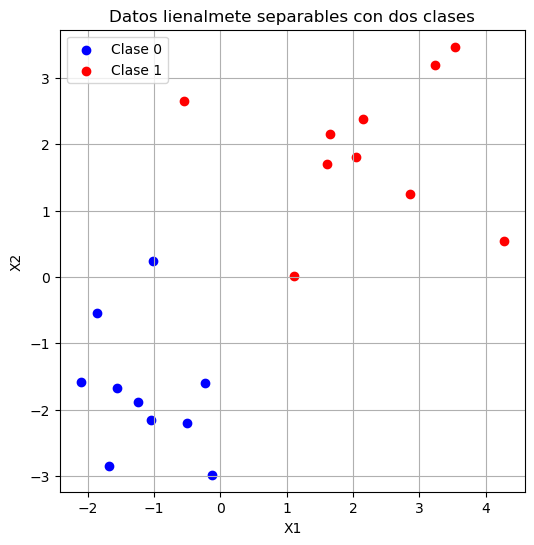

In [5]:
# Graficar datos
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Clase 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Clase 1')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Datos lienalmete separables con dos clases')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [6]:
# Entrenar perceptrón (elige "sigmoide" o "lineal")

print('tamaño X_bias: ', X_bias.shape)
print('tamaño y: ', y.shape)

final_weights, iter_weights = train_perceptron(X_bias, y, activation="sigmoide", lr=0.1, epochs=10)

tamaño X_bias:  (20, 3)
tamaño y:  (20,)


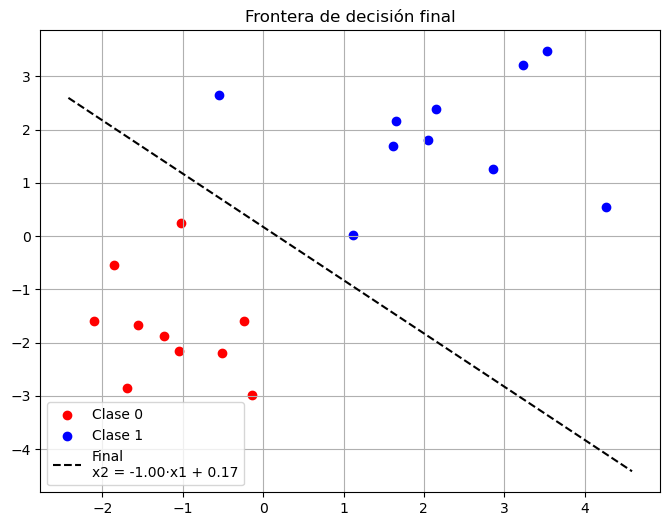

In [7]:
# Gráfico final
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Clase 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Clase 1')
plot_decision_boundary(plt.gca(), final_weights, label=f"Final\n{format_eq(final_weights)}")
plt.title("Frontera de decisión final")
plt.legend()
plt.grid(True)
plt.show()

## Casos No Linealmente separables

In [8]:
from sklearn.datasets import make_circles
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.utils import shuffle


tamaño X_bias: (200, 3)
tamaño y: (200,)


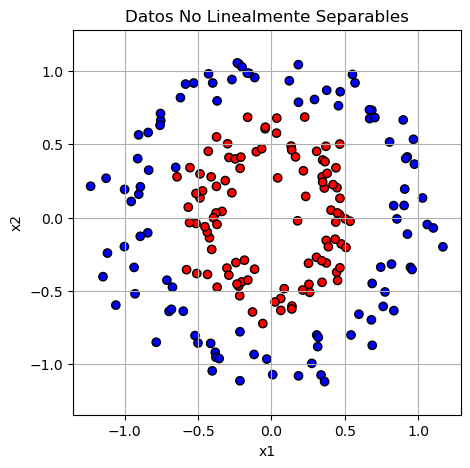

In [9]:
# Generar datos NO linealmente separables
X, y = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=0)

# Añadir término de bias
X_bias = np.hstack([X, np.ones((X.shape[0], 1))])

print('tamaño X_bias:', X_bias.shape)
print('tamaño y:', y.shape)

# Visualización de los datos
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title('Datos No Linealmente Separables')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.grid(True)
plt.show()

tamaño X_bias:  (200, 3)
tamaño y:  (200,)


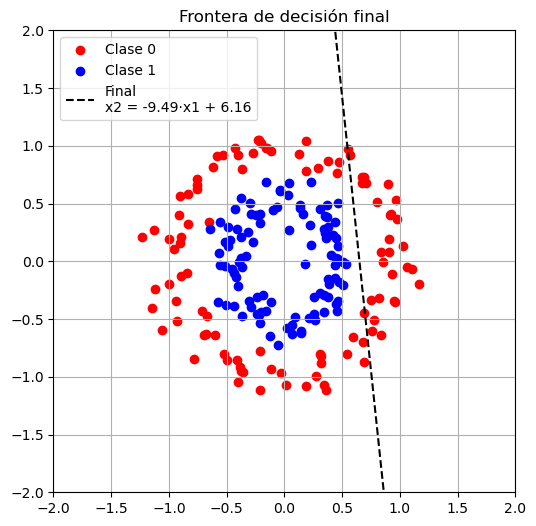

In [10]:
# Entrenar perceptrón (elige "sigmoide" o "lineal")

print('tamaño X_bias: ', X_bias.shape)
print('tamaño y: ', y.shape)

final_weights, iter_weights = train_perceptron(X_bias, y, activation="sigmoide", lr=0.1, epochs=10)


# Gráfico final
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Clase 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Clase 1')
plot_decision_boundary(plt.gca(), final_weights, label=f"Final\n{format_eq(final_weights)}")
plt.title("Frontera de decisión final")
plt.legend()
plt.grid(True)
# Límites de los ejes
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal')  # Mantener proporciones iguales

plt.show()


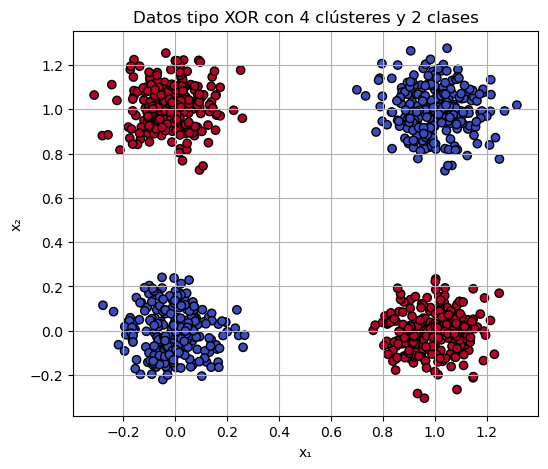

In [11]:

# ======= Generar datos XOR =======
# Cuatro puntos principales del XOR
Xc = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
yc = np.array([0, 1, 1, 0])

# Repetir puntos para obtener más muestras (agregando ruido)
X = np.vstack([Xc + np.random.normal(scale=0.1, size=Xc.shape) for _ in range(250)])
y = np.hstack([yc for _ in range(250)])

# Barajar
X, y = shuffle(X, y, random_state=42)

# Añadir término de bias
X_bias = np.hstack([X, np.ones((X.shape[0], 1))])

# XOR: redondear primero y luego convertir a int
x1 = X[:, 0].round().astype(int)
x2 = X[:, 1].round().astype(int)
y = (x1 ^ x2).astype(int)

# Visualización
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("Datos tipo XOR con 4 clústeres y 2 clases")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.grid(True)
plt.show()

tamaño X_bias:  (1000, 3)
tamaño y:  (1000,)


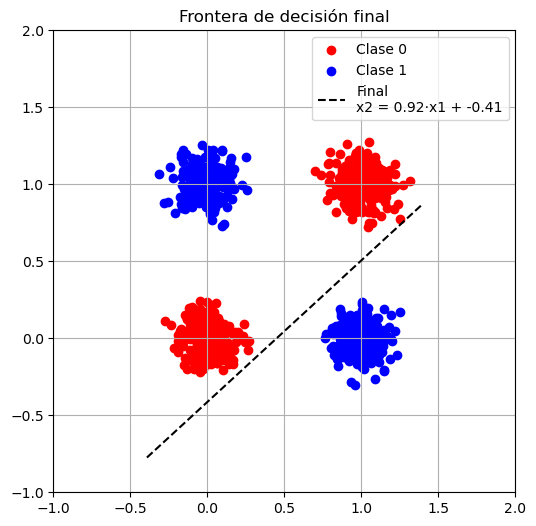

In [12]:
# Entrenar perceptrón (elige "sigmoide" o "lineal")

print('tamaño X_bias: ', X_bias.shape)
print('tamaño y: ', y.shape)

final_weights, iter_weights = train_perceptron(X_bias, y, activation="sigmoide", lr=0.1, epochs=10)


# Gráfico final
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Clase 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Clase 1')
plot_decision_boundary(plt.gca(), final_weights, label=f"Final\n{format_eq(final_weights)}")
plt.title("Frontera de decisión final")
plt.legend()
plt.grid(True)
# Límites de los ejes
plt.xlim(-1, 2)
plt.ylim(-1, 2)
plt.gca().set_aspect('equal')  # Mantener proporciones iguales

plt.show()

tamaño X:  (1000, 2)
tamaño y:  (1000,)


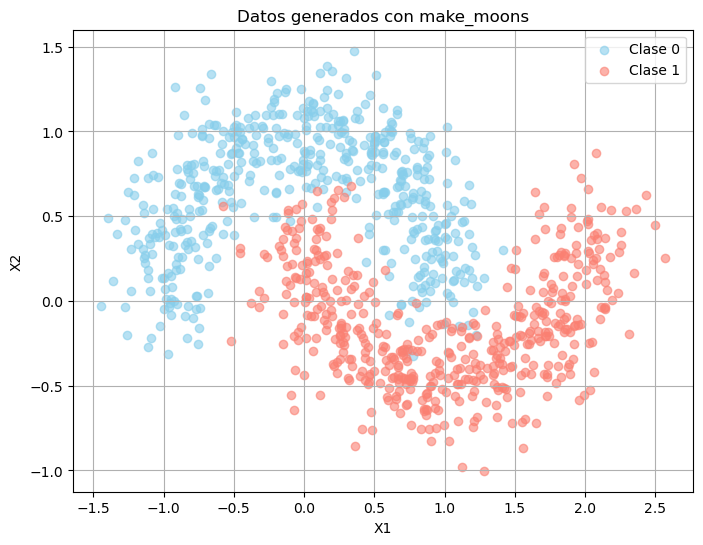

In [13]:
# Crear datos MOONS
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)


# Añadir término de bias
X_bias = np.hstack([X, np.ones((X.shape[0], 1))])

print('tamaño X: ', X.shape)
print('tamaño y: ', y.shape)

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='skyblue', label='Clase 0', alpha=0.6)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='salmon', label='Clase 1', alpha=0.6)
plt.title("Datos generados con make_moons")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)
plt.show()


tamaño X_bias:  (1000, 3)
tamaño y:  (1000,)


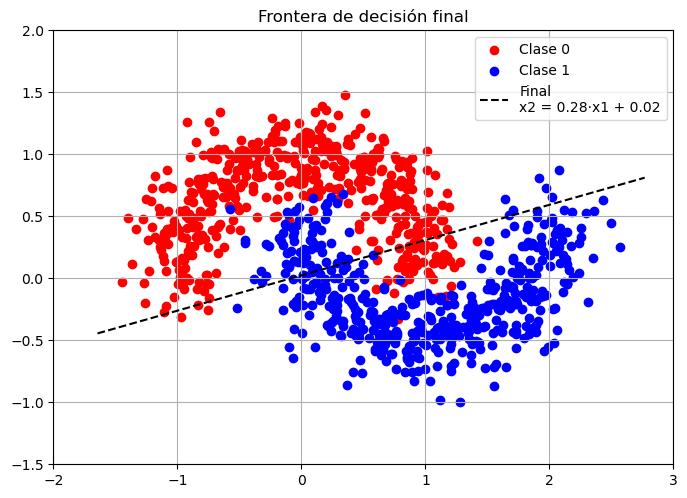

In [14]:
# Entrenar perceptrón (elige "sigmoide" o "lineal")

print('tamaño X_bias: ', X_bias.shape)
print('tamaño y: ', y.shape)

final_weights, iter_weights = train_perceptron(X_bias, y, activation="sigmoide", lr=0.1, epochs=10)


# Gráfico final
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Clase 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Clase 1')
plot_decision_boundary(plt.gca(), final_weights, label=f"Final\n{format_eq(final_weights)}")
plt.title("Frontera de decisión final")
plt.legend()
plt.grid(True)
# Límites de los ejes
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.gca().set_aspect('equal')  # Mantener proporciones iguales

plt.show()

In [15]:
def generate_spirals(n_samples=1000, noise=0.1, angular_offset=np.pi):
    n = n_samples // 2  # muestras por clase
    X = []
    y = []

    # Radio común
    r = np.linspace(0.0, 1, n)

    # Espiral 1 (Clase 0)
    t0 = 4 * np.pi * r + np.random.randn(n) * noise
    x0 = r * np.cos(t0)
    y0 = r * np.sin(t0)
    X.append(np.c_[x0, y0])
    y.extend([0] * n)

    # Espiral 2 (Clase 1), mismo sentido pero con desplazamiento angular
    t1 = 4 * np.pi * r + angular_offset + np.random.randn(n) * noise
    x1 = r * np.cos(t1)
    y1 = r * np.sin(t1)
    X.append(np.c_[x1, y1])
    y.extend([1] * n)

    X = np.vstack(X)
    y = np.array(y)
    return X, y

tamaño X: (1000, 2)
tamaño y: (1000,)


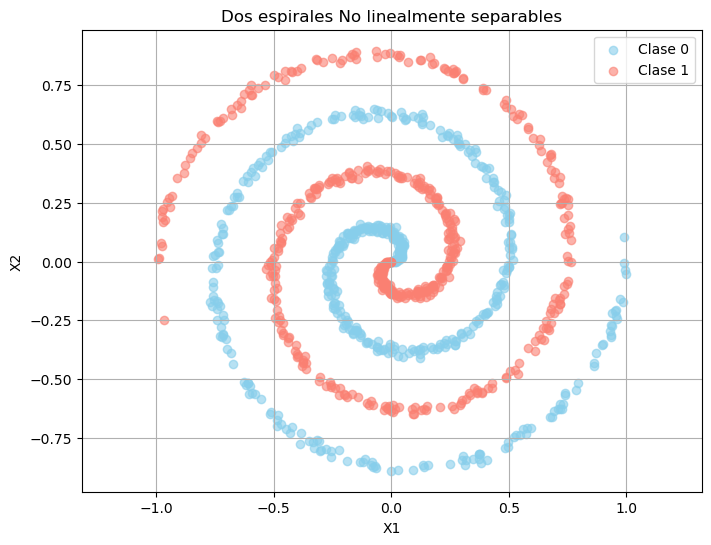

In [16]:
# Generar los datos
X, y = generate_spirals(n_samples=1000, noise=0.15, angular_offset=np.pi)

# Añadir término de bias
X_bias = np.hstack([X, np.ones((X.shape[0], 1))])

print('tamaño X:', X.shape)
print('tamaño y:', y.shape)

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='skyblue', label='Clase 0', alpha=0.6)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='salmon', label='Clase 1', alpha=0.6)
plt.title("Dos espirales No linealmente separables")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

tamaño X_bias:  (1000, 3)
tamaño y:  (1000,)


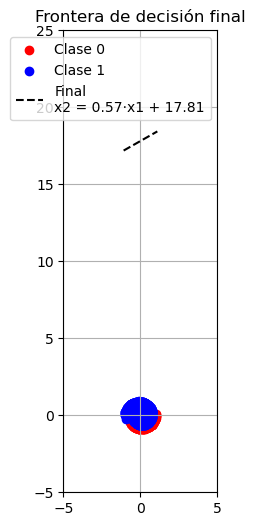

In [17]:
# Entrenar perceptrón (elige "sigmoide" o "lineal")

print('tamaño X_bias: ', X_bias.shape)
print('tamaño y: ', y.shape)

final_weights, iter_weights = train_perceptron(X_bias, y, activation="sigmoide", lr=0.1, epochs=100)


# Gráfico final
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Clase 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Clase 1')
plot_decision_boundary(plt.gca(), final_weights, label=f"Final\n{format_eq(final_weights)}")
plt.title("Frontera de decisión final")
plt.legend()
plt.grid(True)
# Límites de los ejes
plt.xlim(-5, 5)
plt.ylim(-5, 25)
plt.gca().set_aspect('equal')  # Mantener proporciones iguales

plt.show()

# Red Neuronal MULTICAPA 

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.utils import shuffle
from sklearn.neural_network import MLPClassifier

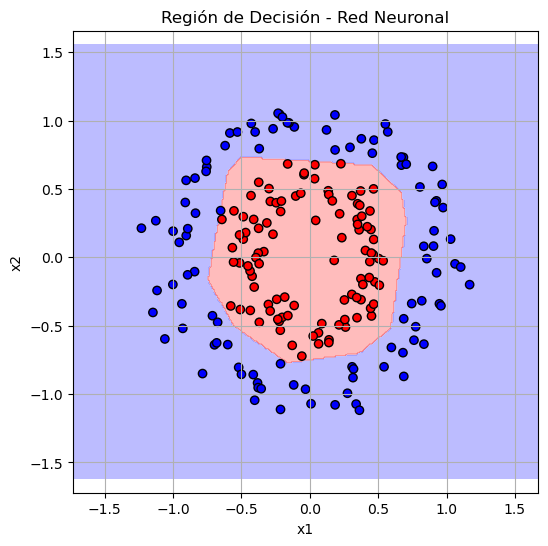

In [19]:
# ======= Generar datos no linealmente separables =======
X, y = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=0)



# ======= Entrenar red neuronal =======
# Red neuronal con una capa oculta de 10 neuronas, activación ReLU
clf = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',
                    solver='adam', max_iter=5000, random_state=42)

clf.fit(X, y)

# ======= Visualización del espacio de decisión =======
# Crear una malla de puntos para evaluar la red
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
                     np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Obtener las predicciones de la red para cada punto
Z = clf.predict(grid).reshape(xx.shape)

# Dibujar la región de decisión
plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title('Región de Decisión - Red Neuronal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.grid(True)
plt.show()

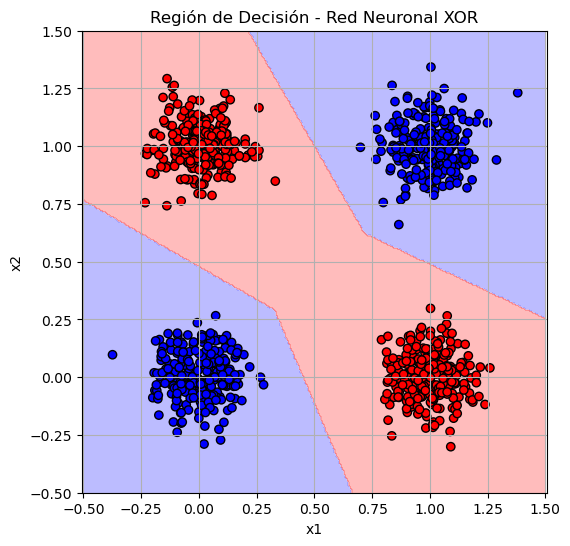

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.utils import shuffle

# ======= Generar datos XOR =======
# Cuatro puntos principales del XOR
Xc = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
yc = np.array([0, 1, 1, 0])

# Repetir puntos para obtener más muestras (agregando ruido)
X = np.vstack([Xc + np.random.normal(scale=0.1, size=Xc.shape) for _ in range(250)])
y = np.hstack([yc for _ in range(250)])

# Barajar
X, y = shuffle(X, y, random_state=42)

# ======= Entrenar red neuronal =======
clf = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',
                    solver='adam', max_iter=5000, random_state=42)

clf.fit(X, y)

# ======= Visualización del espacio de decisión =======
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title('Región de Decisión - Red Neuronal XOR')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.grid(True)
plt.show()


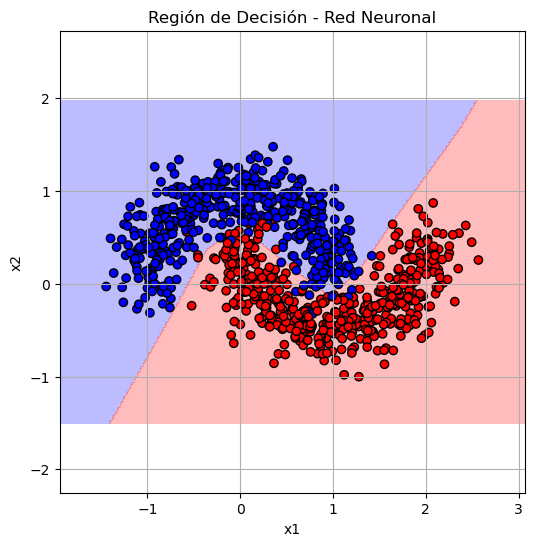

In [21]:
# Crear datos MOONS
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# ======= Entrenar red neuronal =======
# Red neuronal con una capa oculta de 10 neuronas, activación ReLU
clf = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',
                    solver='adam', max_iter=5000, random_state=42)

clf.fit(X, y)

# ======= Visualización del espacio de decisión =======
# Crear una malla de puntos para evaluar la red
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
                     np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Obtener las predicciones de la red para cada punto
Z = clf.predict(grid).reshape(xx.shape)

# Dibujar la región de decisión
plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title('Región de Decisión - Red Neuronal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.grid(True)
plt.show()

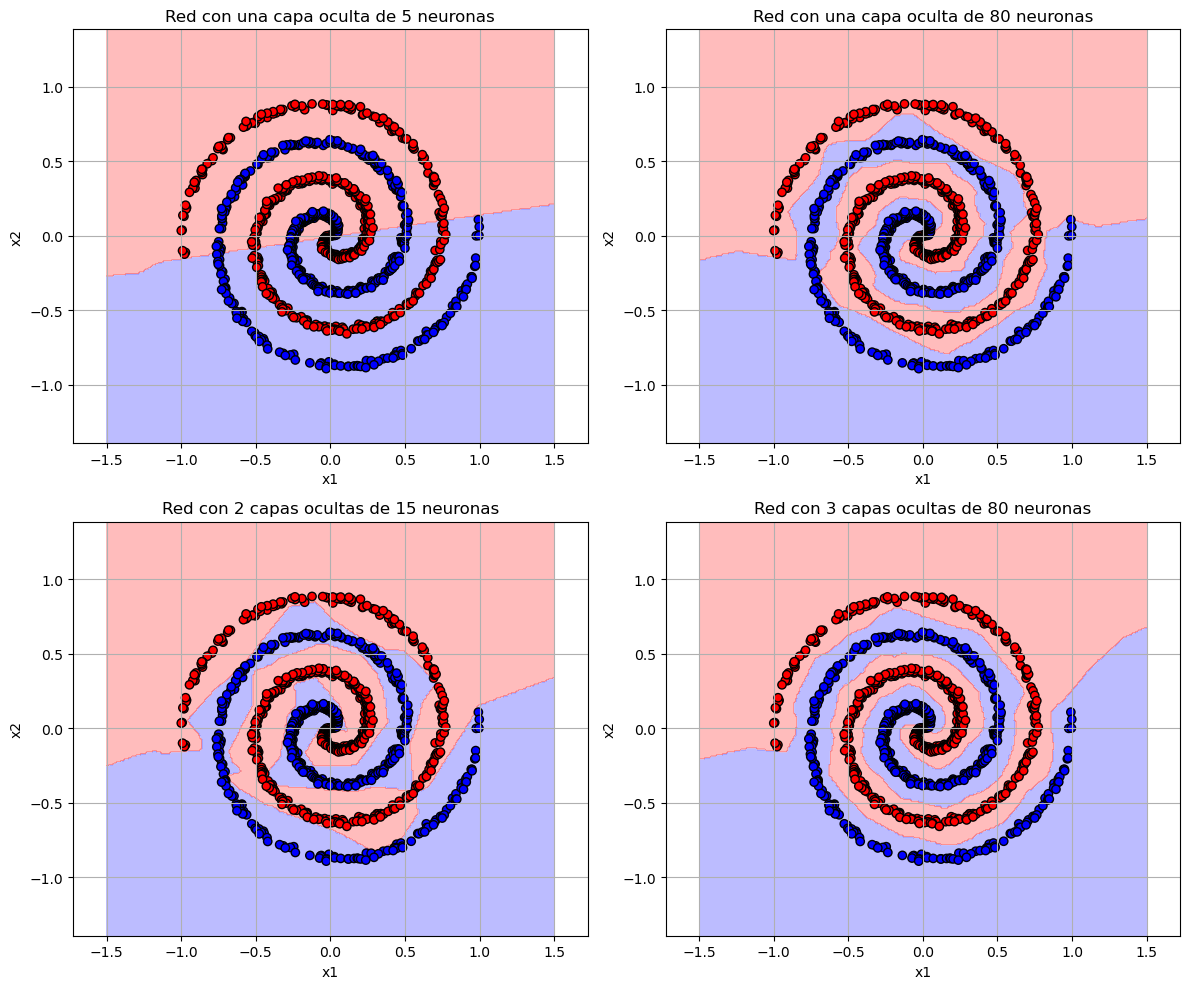

In [22]:
# Generar los datos ESPIRALES
X, y = generate_spirals(n_samples=1000, noise=0.15, angular_offset=np.pi)

# ======= Entrenar red neuronal =======
# Red neuronal con una capa oculta de 5 neuronas, activación ReLU
clf1 = MLPClassifier(hidden_layer_sizes=(5,), activation='relu',
                    solver='adam', max_iter=5000, random_state=42)

clf1.fit(X, y)

# Red neuronal con UNA capas ocultas de 80 neuronas, activación ReLU
clf2 = MLPClassifier(hidden_layer_sizes=(80,), activation='relu',
                    solver='adam', max_iter=5000, random_state=42)

clf2.fit(X, y)

# Red neuronal con DOS capas ocultas de 15 neuronas, activación ReLU
clf3 = MLPClassifier(hidden_layer_sizes=(15,15,), activation='relu',
                    solver='adam', max_iter=5000, random_state=42)

clf3.fit(X, y)

# Red neuronal con TRES capas ocultas de 80 neuronas, activación ReLU
clf4 = MLPClassifier(hidden_layer_sizes=(80,80,80,), activation='relu',
                    solver='adam', max_iter=5000, random_state=42)

clf4.fit(X, y)

# ======= Visualización del espacio de decisión =======
# Crear una malla de puntos para evaluar la red
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
                     np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Obtener las predicciones de la red para cada punto
Z1 = clf1.predict(grid).reshape(xx.shape)
Z2 = clf2.predict(grid).reshape(xx.shape)
Z3 = clf3.predict(grid).reshape(xx.shape)
Z4 = clf4.predict(grid).reshape(xx.shape)

# ======= Visualización: 3 subfiguras =======
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Subfigura 1: Red con una capa oculta de 5 neuronas
axes[0,0].contourf(xx, yy, Z1, cmap='bwr', alpha=0.3)
axes[0,0].scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
axes[0,0].set_title('Red con una capa oculta de 5 neuronas')
axes[0,0].set_xlabel('x1')
axes[0,0].set_ylabel('x2')
axes[0,0].axis('equal')
axes[0,0].grid(True)

# Subfigura 2: Red con una capa oculta de 80 neuronas
axes[0,1].contourf(xx, yy, Z2, cmap='bwr', alpha=0.3)
axes[0,1].scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
axes[0,1].set_title('Red con una capa oculta de 80 neuronas')
axes[0,1].set_xlabel('x1')
axes[0,1].set_ylabel('x2')
axes[0,1].axis('equal')
axes[0,1].grid(True)

# Subfigura 3: Red con 2 capas ocultas de 15 neuronas
axes[1,0].contourf(xx, yy, Z3, cmap='bwr', alpha=0.3)
axes[1,0].scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
axes[1,0].set_title('Red con 2 capas ocultas de 15 neuronas')
axes[1,0].set_xlabel('x1')
axes[1,0].set_ylabel('x2')
axes[1,0].axis('equal')
axes[1,0].grid(True)

# Subfigura 3: Red con 3 capas ocultas de 80 neuronas
axes[1,1].contourf(xx, yy, Z4, cmap='bwr', alpha=0.3)
axes[1,1].scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
axes[1,1].set_title('Red con 3 capas ocultas de 80 neuronas')
axes[1,1].set_xlabel('x1')
axes[1,1].set_ylabel('x2')
axes[1,1].axis('equal')
axes[1,1].grid(True)


# Ajustar y mostrar
plt.tight_layout()
plt.show()

---

# SOBREAJUSTE
---

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [24]:
# ====== Funciones básicas ======
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

def one_hot(y, num_classes):
    return np.eye(num_classes)[y]

# ====== Clase de red neuronal desde cero ======
class RedNeuronal:
    def __init__(self, capas_ocultas, input_size, output_size):
        self.capas = []
        self.biases = []

        sizes = [input_size] + capas_ocultas + [output_size]

        for i in range(len(sizes) - 1):
            W = np.random.randn(sizes[i], sizes[i+1]) * np.sqrt(1 / sizes[i])
            b = np.zeros((1, sizes[i+1]))
            self.capas.append(W)
            self.biases.append(b)

    def forward(self, X):
        activaciones = [X]
        z_list = []
        for i in range(len(self.capas)):
            Z = activaciones[-1] @ self.capas[i] + self.biases[i]
            A = sigmoid(Z)
            z_list.append(Z)
            activaciones.append(A)
        return activaciones, z_list

    def backward(self, X, y, activaciones, z_list, lr=0.1):
        m = X.shape[0]
        deltas = [activaciones[-1] - y]  # salida: error

        # backpropagation
        for i in reversed(range(len(self.capas) - 1)):
            dZ = deltas[0] @ self.capas[i+1].T * sigmoid_deriv(z_list[i])
            deltas.insert(0, dZ)

        # actualizar pesos
        for i in range(len(self.capas)):
            dW = activaciones[i].T @ deltas[i] / m
            db = np.mean(deltas[i], axis=0, keepdims=True)
            self.capas[i] -= lr * dW
            self.biases[i] -= lr * db

    def entrenar(self, X, y, epochs=1000, lr=0.1):
        for ep in range(epochs):
            activaciones, z_list = self.forward(X)
            self.backward(X, y, activaciones, z_list, lr)

    def predecir(self, X):
        A, _ = self.forward(X)
        return np.argmax(A[-1], axis=1)


# ====== Visualización ======
def graficar_frontera(modelo, epocas, X, y):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = modelo.predecir(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Extraer arquitectura
    capas_ocultas = [W.shape[1] for W in modelo.capas[:-1]]
    n_capas = len(capas_ocultas)

    # Preparar título
    titulo = f"Frontera de decisión\nCapas ocultas: {n_capas} | Neuronas: {capas_ocultas} | Épocas: {epocas}"

    # Graficar
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(titulo, fontsize=12)
    plt.xlabel('x₁')
    plt.ylabel('x₂')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


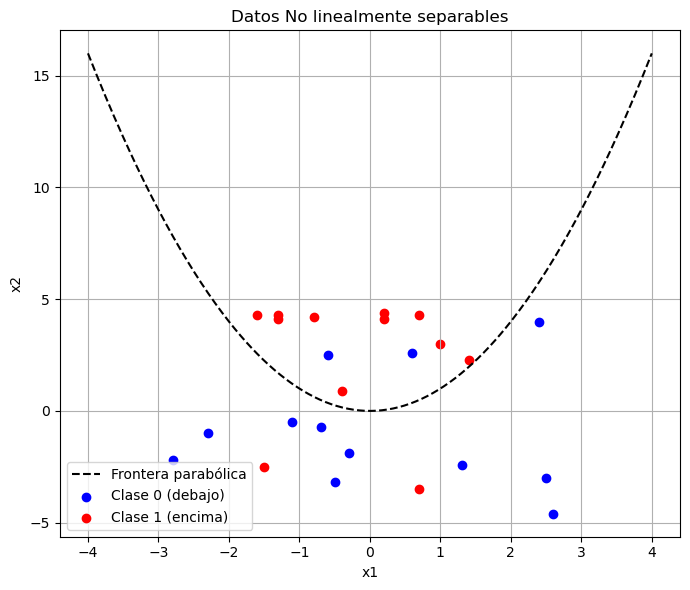

In [25]:
# ==== Agregar datos manualmente (opcional) ====
# Clase 0: puntos debajo (y también algunos arriba de la parábola)
X0 = np.array([
    [-0.5, -3.19], [2.5, -3.0], [-0.3, -1.9], [-0.7, -0.7], [-1.1, -0.5],
    [-2.8, -2.2], [2.4, 4.0], [2.6, -4.6], [1.3, -2.4], [-2.3, -1.0],
    [0.6, 2.6], [-0.6, 2.5]
])

y0 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Clase 1: puntos encima (y también algunos posiblemente debajo de la parábola)
X1 = np.array([
    [1.0, 3.0], [-0.8, 4.2], [0.7, 4.3], [1.4, 2.3], [0.2, 4.1],
    [-1.3, 4.1], [-0.4, 0.9], [-1.6, 4.3], [-1.3, 4.3], [0.2, 4.4],
    [0.7, -3.5], [-1.5, -2.5]
])
y1 = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

#print("=== Datos generados automáticamente ===")
#print("Clase 0 (debajo de la parábola):")
#print(X0.shape)
#print(X0)
#print(y0.shape)
#print(y0)
#
#print("\nClase 1 (encima de la parábola):")
#print(X1.shape)
#print(X1)
#print(y1.shape)
#print(y1)

X = np.vstack([X0, X1])
y = np.vstack([y0, y1])

# ==== Visualización ====
# ==== Parámetros de la parábola ====
a, b, c = 1.0, 0.0, 0.0  # y = ax^2 + bx + c
x_vals = np.linspace(-4, 4, 400)
y_parabola = a * x_vals**2 + b * x_vals + c

plt.figure(figsize=(7,6))
plt.plot(x_vals, y_parabola, 'k--', label='Frontera parabólica')
plt.scatter(X0[:,0], X0[:,1], color='blue', label='Clase 0 (debajo)')
plt.scatter(X1[:,0], X1[:,1], color='red', label='Clase 1 (encima)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Datos No linealmente separables')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# ====== Datos de ejemplo ======
#X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)


# Ejemplo simple (puedes reemplazar esto):
#X = np.array([[0, 0], [1, 0], [0, 1], [1, 1],
#              [2, 2], [3, 2], [2, 3], [3, 3]])
#y = np.array([0, 0, 0, 0, 1, 1, 1, 1])


X0 = np.array([
    [-0.5, -3.19], [2.5, -3.0], [-0.3, -1.9], [-0.7, -0.7], [-1.1, -0.5],
    [-2.8, -2.2], [2.4, 4.0], [2.6, -4.6], [1.3, -2.4], [-2.3, -1.0],
    [0.6, 2.6], [-0.6, 2.5]
])

y0 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Clase 1: puntos encima (y también algunos posiblemente debajo de la parábola)
X1 = np.array([
    [1.0, 3.0], [-0.8, 4.2], [0.7, 4.3], [1.4, 2.3], [0.2, 4.1],
    [-1.3, 4.1], [-0.4, 0.9], [-1.6, 4.3], [-1.3, 4.3], [0.2, 4.4],
    [0.7, -3.5], [-1.5, -2.5]
])
y1 = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


## Aumentar datos (más ruido)
#
#np.random.seed(0)
#ruido_clase0 = np.random.normal(0, 0.5, (10, 2))
#ruido_clase1 = np.random.normal(0, 0.5, (10, 2))
#
#X0 = np.vstack([X0, ruido_clase0 + np.array([0, 2])])  # ruido cerca del medio
#X1 = np.vstack([X1, ruido_clase1 + np.array([0, -1])])
#
#y0 = np.concatenate([y0, np.zeros(10)])
#y1 = np.concatenate([y1, np.ones(10)])


X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])
y = y.astype(int)

print("Forma de X:", X.shape)      # (24, 2)
print("Forma de y:", y.shape)      # (24,)
print("Clases únicas:", np.unique(y))

# Preparar clases one-hot
n_clases = len(np.unique(y))
y_onehot = one_hot(y, n_clases)

Forma de X: (24, 2)
Forma de y: (24,)
Clases únicas: [0 1]


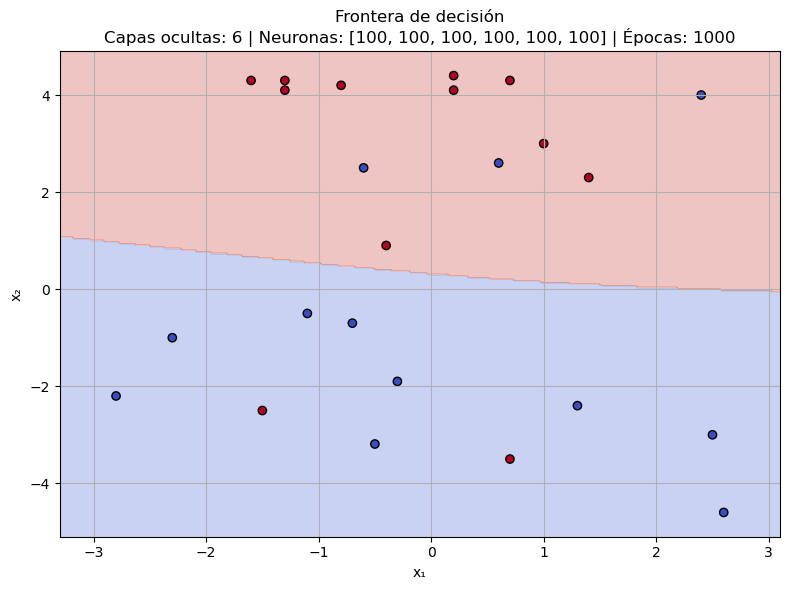

In [27]:
# Red grande para sobreajuste extremo
red = RedNeuronal(
    capas_ocultas=[100, 100, 100, 100, 100, 100],  # muchas capas y neuronas
    input_size=X.shape[1],
    output_size=n_clases
)

# Entrenamiento prolongado
epochs=1000
red.entrenar(X, one_hot(y, n_clases), epochs, lr=0.1)

# Visualización con los datos de entrenamiento
graficar_frontera(red, epochs, X, y)

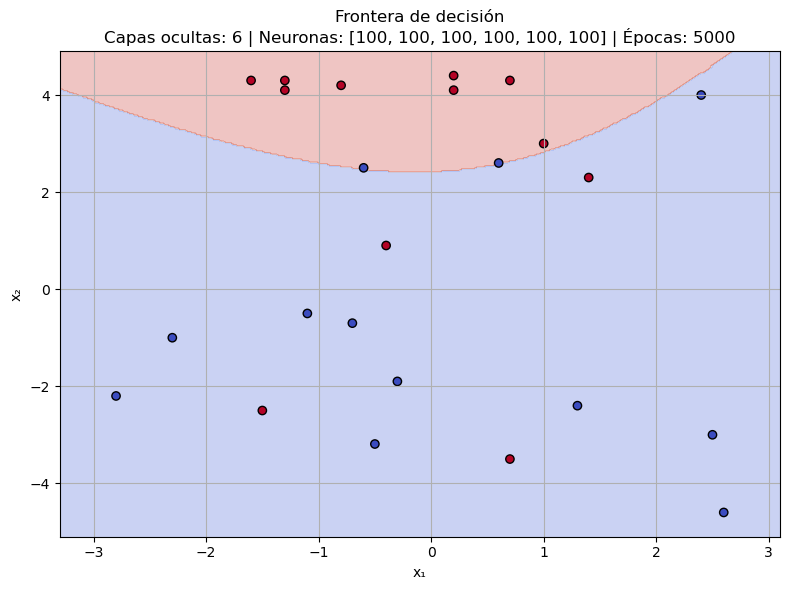

In [28]:
# Red grande para sobreajuste extremo
red = RedNeuronal(
    capas_ocultas=[100, 100, 100, 100, 100, 100],  # muchas capas y neuronas
    input_size=X.shape[1],
    output_size=n_clases
)

# Entrenamiento prolongado
epochs=5000
red.entrenar(X, one_hot(y, n_clases), epochs, lr=0.1)

# Visualización con los datos de entrenamiento
graficar_frontera(red, epochs, X, y)

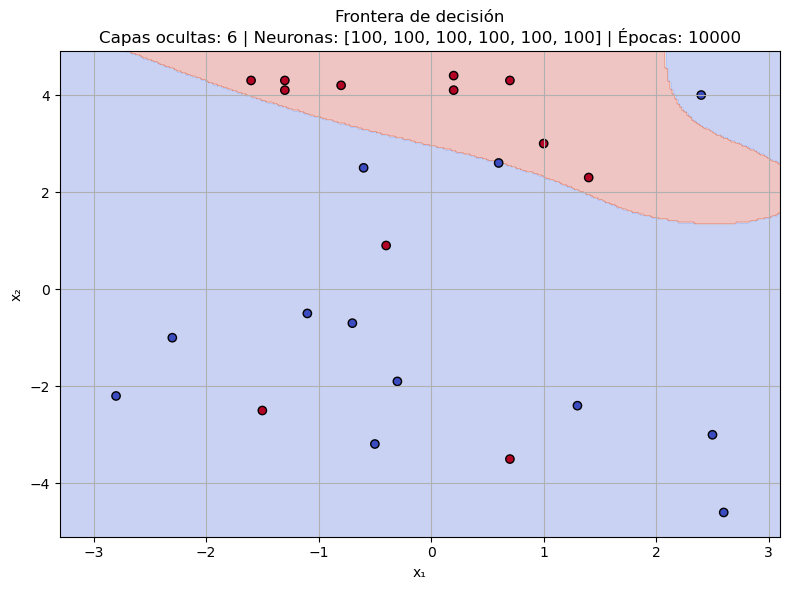

In [29]:
# Red grande para sobreajuste extremo
red = RedNeuronal(
    capas_ocultas=[100, 100, 100, 100, 100, 100],  # muchas capas y neuronas
    input_size=X.shape[1],
    output_size=n_clases
)

# Entrenamiento prolongado
epochs=10000
red.entrenar(X, one_hot(y, n_clases), epochs, lr=0.1)

# Visualización con los datos de entrenamiento
graficar_frontera(red, epochs, X, y)


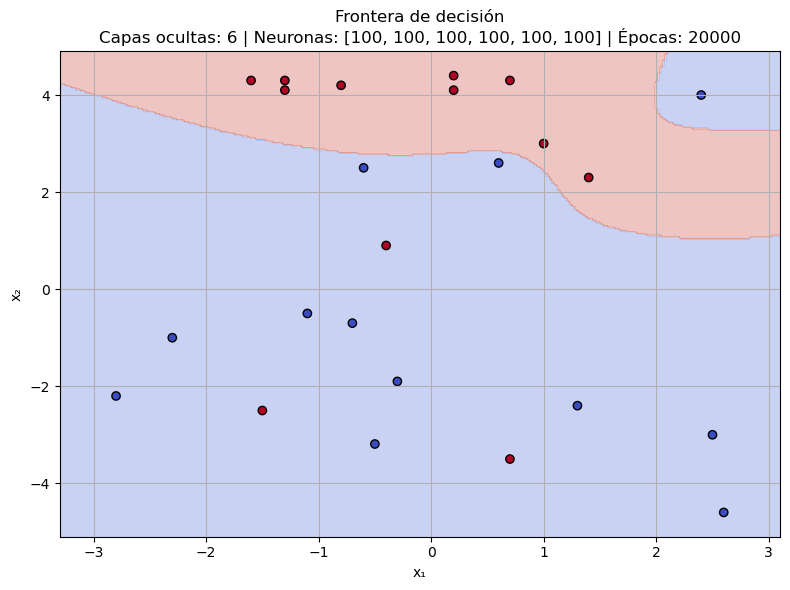

In [30]:
# Red grande para sobreajuste extremo
red = RedNeuronal(
    capas_ocultas=[100, 100, 100, 100, 100, 100],  # muchas capas y neuronas
    input_size=X.shape[1],
    output_size=n_clases
)

# Entrenamiento prolongado
epochs=20000
red.entrenar(X, one_hot(y, n_clases), epochs, lr=0.1)

# Visualización con los datos de entrenamiento
graficar_frontera(red, epochs, X, y)


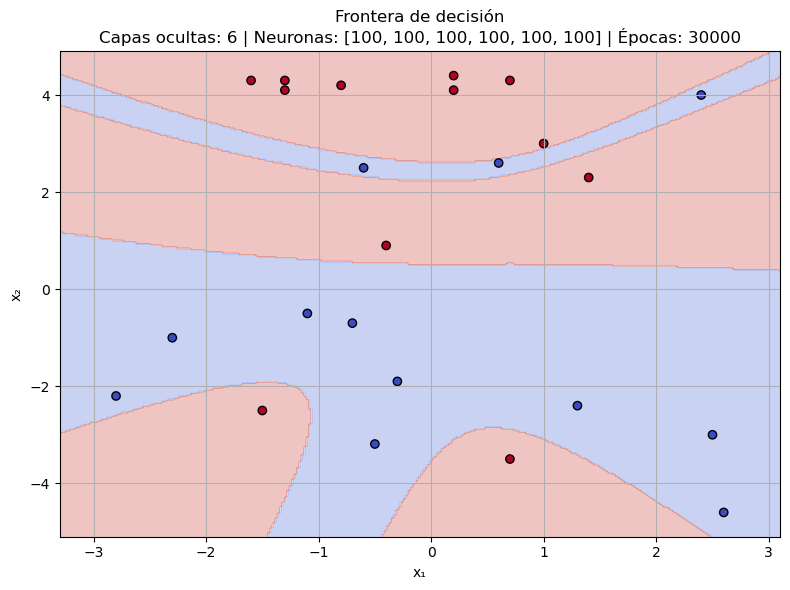

In [31]:
# Red grande para sobreajuste extremo
red = RedNeuronal(
    capas_ocultas=[100, 100, 100, 100, 100, 100],  # muchas capas y neuronas
    input_size=X.shape[1],
    output_size=n_clases
)

# Entrenamiento prolongado
epochs=30000
red.entrenar(X, one_hot(y, n_clases), epochs, lr=0.1)

# Visualización con los datos de entrenamiento
graficar_frontera(red, epochs, X, y)

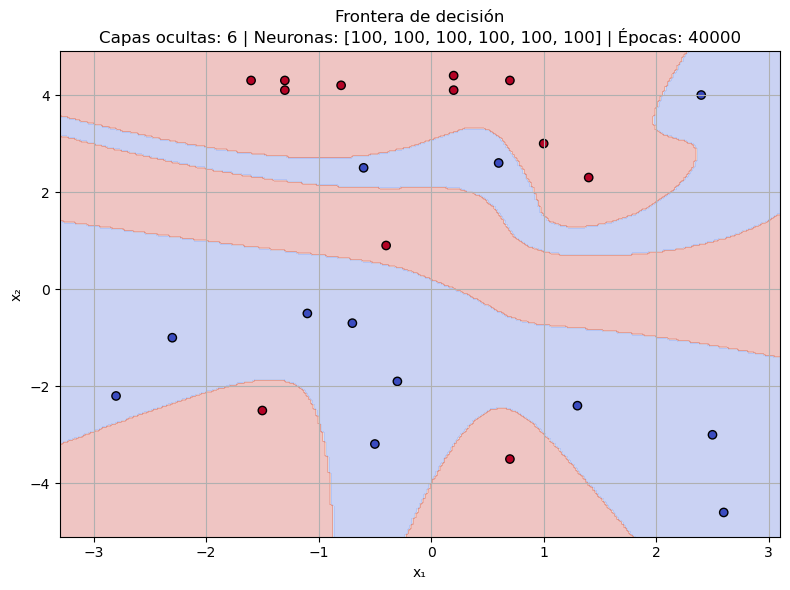

In [32]:
# Red grande para sobreajuste extremo
red = RedNeuronal(
    capas_ocultas=[100, 100, 100, 100, 100, 100],  # muchas capas y neuronas
    input_size=X.shape[1],
    output_size=n_clases
)

# Entrenamiento prolongado
epochs=40000
red.entrenar(X, one_hot(y, n_clases), epochs, lr=0.1)

# Visualización con los datos de entrenamiento
graficar_frontera(red, epochs, X, y)

---

# RED NEURONAL MULTICAPA DESDE CERO (Usando solo Numpy)
## Funciones de Activación

**Características:**
- Arquitectura definida por el usuario.
- Diferentes funciones de activación por capa oculta.
- `Softmax` en la capa de salida.
- Entrenamiento por mini-batches.
- Visualización de pérdida y precisión.
- Lectura y escritura de parámetros entrenados.

In [33]:
import numpy as np
import matplotlib.pyplot as plt


##  Funciones de activación y softmax

In [71]:
# Funciones de activación y sus derivadas

# Parámetros estándar para SELU
lambda_selu = 1.0507
alpha_selu = 1.6733


activation_funcs = {
    "relu": (
        lambda x: np.maximum(0, x), # Función de activación
        lambda x: (x > 0).astype(float) # Derivada
    ),
    "tanh": (
        np.tanh,  # Función de activación
        lambda x: 1 - np.tanh(x)**2 # Derivada
    ),
    "sigmoid": (
        lambda x: 1 / (1 + np.exp(-x)), # Función de activación
        lambda x: (1 / (1 + np.exp(-x))) * (1 - 1 / (1 + np.exp(-x))) # Derivada
    ),
    "linear": (
        lambda x: x,  # Función de activación
        lambda x: np.ones_like(x)  # Derivada
    ),
    "selu": (
        lambda x: lambda_selu * np.where(x > 0, x, alpha_selu * (np.exp(x) - 1)),
        lambda x: lambda_selu * np.where(x > 0, 1, alpha_selu * np.exp(x))
    )
}



# Función softmax
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


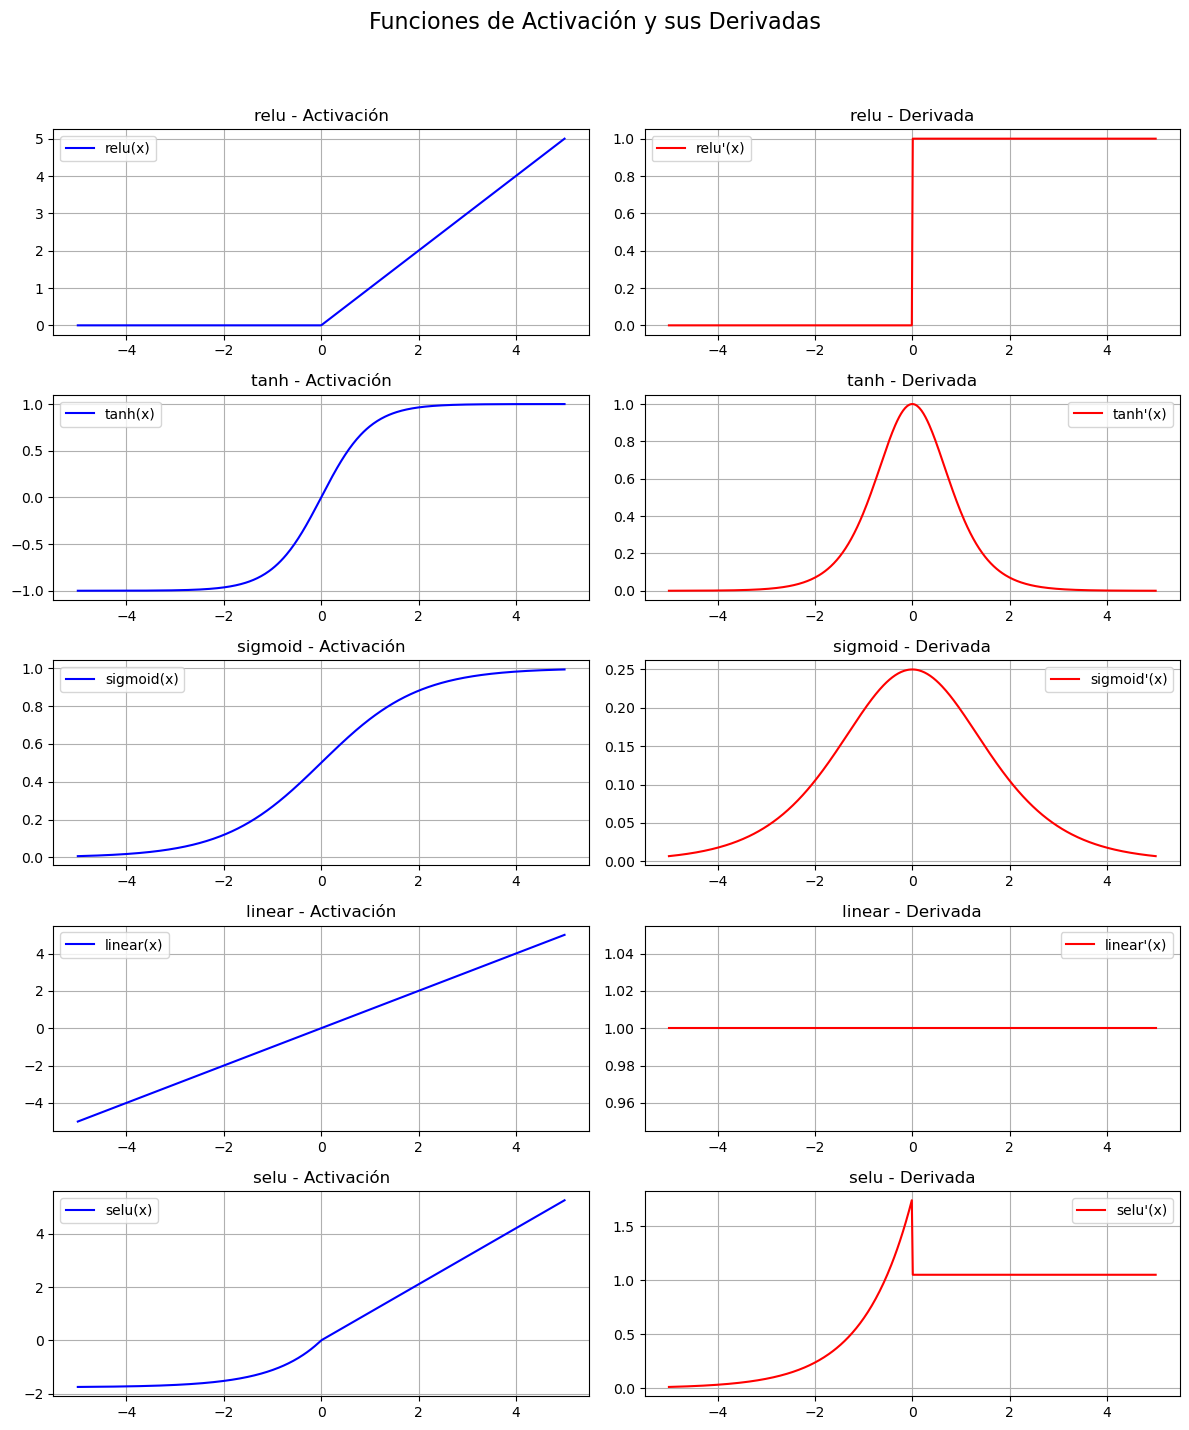

In [35]:
# Crear un rango de valores
x = np.linspace(-5, 5, 500)

# Graficar cada función
num_funcs = len(activation_funcs)
fig, axs = plt.subplots(num_funcs, 2, figsize=(12, 3 * num_funcs))
#fig, axs = plt.subplots(4, 2, figsize=(12, 14))
fig.suptitle("Funciones de Activación y sus Derivadas", fontsize=16)

for idx, (name, (func, deriv)) in enumerate(activation_funcs.items()):
    y = func(x)
    dy = deriv(x)

    axs[idx, 0].plot(x, y, label=f'{name}(x)', color='blue')
    axs[idx, 0].set_title(f'{name} - Activación')
    axs[idx, 0].grid(True)
    axs[idx, 0].legend()

    axs[idx, 1].plot(x, dy, label=f'{name}\'(x)', color='red')
    axs[idx, 1].set_title(f'{name} - Derivada')
    axs[idx, 1].grid(True)
    axs[idx, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Simulación del gradiente desvanecido

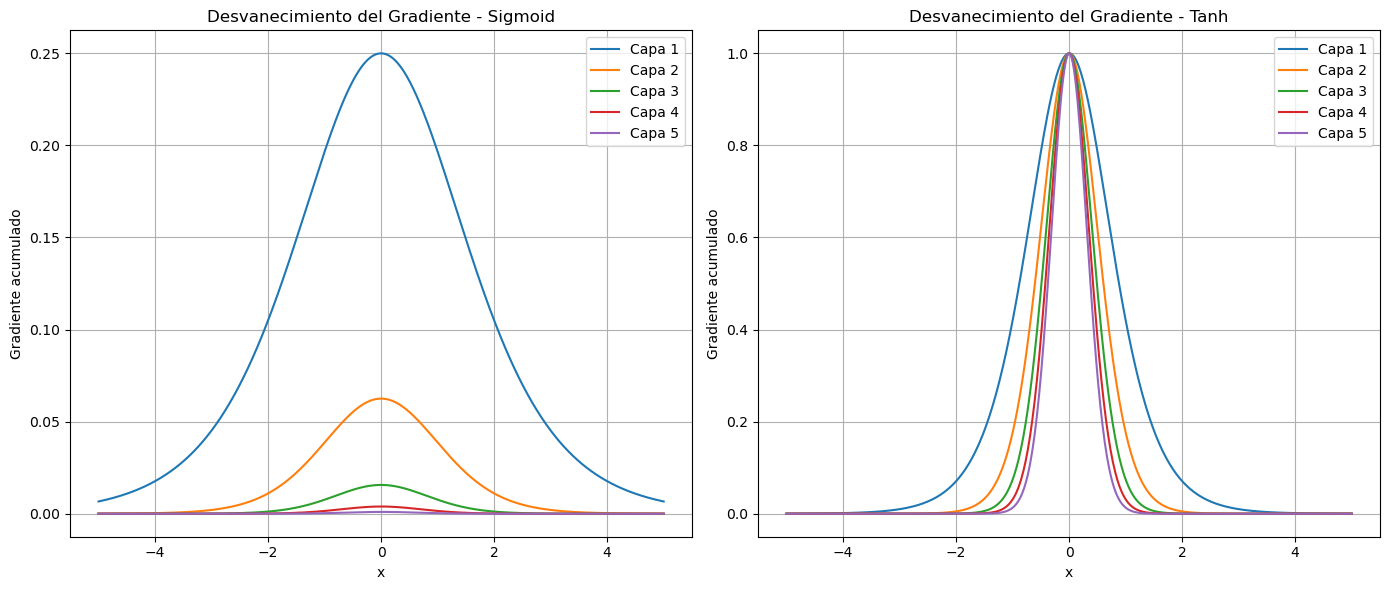

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Derivadas de las funciones de activación
def sigmoid_derivative(x):
    s = 1 / (1 + np.exp(-x))
    return s * (1 - s)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

# Valores de entrada simulados
x_vals = np.linspace(-5, 5, 500)

# Derivadas individuales
sigmoid_grad = sigmoid_derivative(x_vals)
tanh_grad = tanh_derivative(x_vals)

# Número de capas a mostrar
n_layers_to_show = 5

# Preparar figura
plt.figure(figsize=(14, 6))

# Subplot para Sigmoid
plt.subplot(1, 2, 1)
sigmoid_chain = sigmoid_grad.copy()
plt.plot(x_vals, sigmoid_chain, label="Capa 1")
for i in range(2, n_layers_to_show + 1):
    sigmoid_chain *= sigmoid_grad
    plt.plot(x_vals, sigmoid_chain, label=f"Capa {i}")
plt.title("Desvanecimiento del Gradiente - Sigmoid")
plt.xlabel("x")
plt.ylabel("Gradiente acumulado")
plt.legend()
plt.grid(True)

# Subplot para Tanh
plt.subplot(1, 2, 2)
tanh_chain = tanh_grad.copy()
plt.plot(x_vals, tanh_chain, label="Capa 1")
for i in range(2, n_layers_to_show + 1):
    tanh_chain *= tanh_grad
    plt.plot(x_vals, tanh_chain, label=f"Capa {i}")
plt.title("Desvanecimiento del Gradiente - Tanh")
plt.xlabel("x")
plt.ylabel("Gradiente acumulado")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Simulación de explosión del gradiente

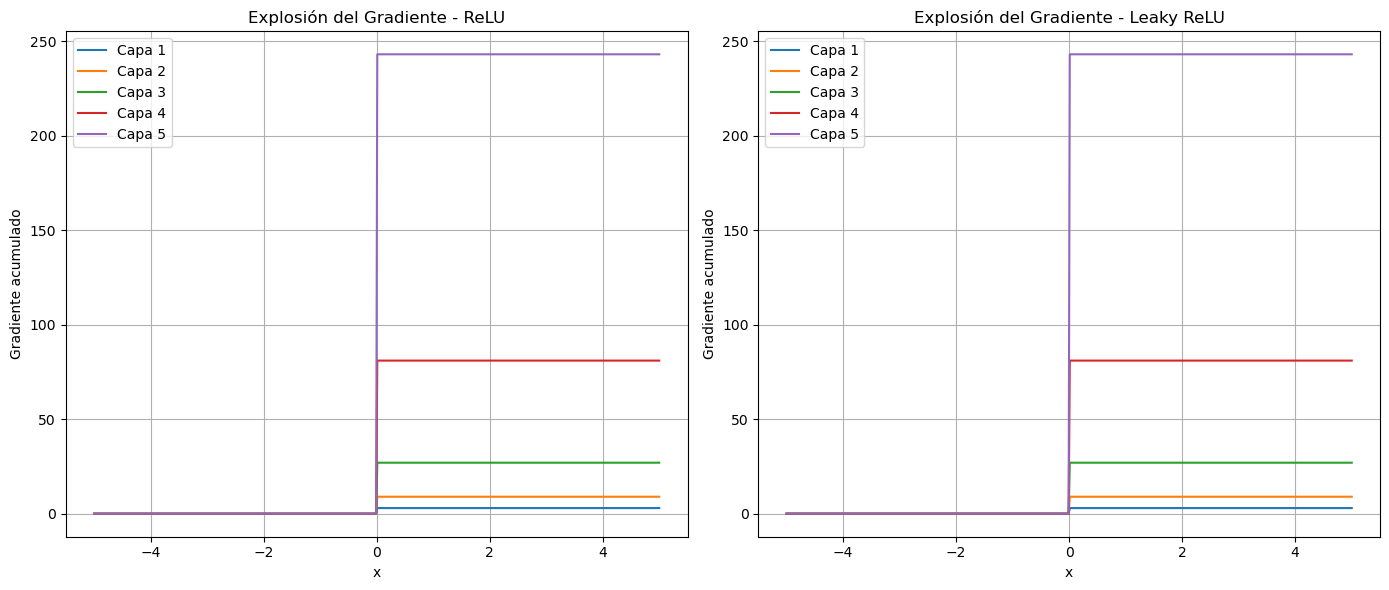

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Funciones de activación
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1.0, alpha)

# Entradas
x_vals = np.linspace(-5, 5, 500)

# Derivadas
relu_der = relu_derivative(x_vals)
leaky_der = leaky_relu_derivative(x_vals)

# Simular multiplicación con pesos grandes
scale = 3.0  # factor artificial para provocar explosión

# Inicialización
relu_chain = relu_der * scale
leaky_chain = leaky_der * scale

# Número de capas
n_layers_to_show = 5

# Crear gráfico
plt.figure(figsize=(14, 6))

# ReLU
plt.subplot(1, 2, 1)
plt.plot(x_vals, relu_chain, label="Capa 1")
for i in range(2, n_layers_to_show + 1):
    relu_chain *= relu_der * scale
    plt.plot(x_vals, relu_chain, label=f"Capa {i}")
plt.title("Explosión del Gradiente - ReLU")
plt.xlabel("x")
plt.ylabel("Gradiente acumulado")
plt.grid(True)
plt.legend()

# Leaky ReLU
plt.subplot(1, 2, 2)
plt.plot(x_vals, leaky_chain, label="Capa 1")
for i in range(2, n_layers_to_show + 1):
    leaky_chain *= leaky_der * scale
    plt.plot(x_vals, leaky_chain, label=f"Capa {i}")
plt.title("Explosión del Gradiente - Leaky ReLU")
plt.xlabel("x")
plt.ylabel("Gradiente acumulado")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


---

# Inicialización **He**

In [72]:
import numpy as np

def init_network(layer_sizes, activations):
    assert len(layer_sizes) - 2 == len(activations), "Activaciones deben coincidir con capas ocultas"
    params = []
    for i in range(len(layer_sizes) - 1):
        W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2. / layer_sizes[i]) # Inicializaciónde He para los pesos 
        b = np.zeros((1, layer_sizes[i+1])) # Inicializacion de los sesgos
        params.append({"W": W, "b": b})
    return {
        "layer_sizes": layer_sizes,
        "activations": activations,
        "params": params,
        "loss_history": [],
        "acc_history": []
    }


### Ejemplo

In [74]:

# Definición de arquitectura
layer_sizes = [4, 16, 8, 3]        # Entrada → Oculta1 → Oculta2 → Salida
activations = ["relu", "relu"]     # Solo para capas ocultas

# Inicializar red
network = init_network(layer_sizes, activations)

# Ver estructura creada
print("Tamaños de capas:", network["layer_sizes"])
print("Activaciones:", network["activations"])
print("Número de capas parametrizadas:", len(network["params"]))

# Inspeccionar pesos y sesgos 
for i, layer in enumerate(network["params"]):
    print(f"Capa {i+1}")
    print("  W shape:", layer["W"].shape)
    print("  b shape:", layer["b"].shape)
    print("-" * 30)

Tamaños de capas: [4, 16, 8, 3]
Activaciones: ['relu', 'relu']
Número de capas parametrizadas: 3
Capa 1
  W shape: (4, 16)
  b shape: (1, 16)
------------------------------
Capa 2
  W shape: (16, 8)
  b shape: (1, 8)
------------------------------
Capa 3
  W shape: (8, 3)
  b shape: (1, 3)
------------------------------


## Propagación hacia adelante (`forward`)

In [75]:
def forward(network, X):
    a = X
    caches = [{"A": a}]
    for i, layer in enumerate(network["params"][:-1]):
        z = np.dot(a, layer["W"]) + layer["b"]
        act_fn, _ = activation_funcs[network["activations"][i]]
        a = act_fn(z)
        caches.append({"Z": z, "A": a})
    z = np.dot(a, network["params"][-1]["W"]) + network["params"][-1]["b"]
    a = softmax(z)
    caches.append({"Z": z, "A": a})
    return a, caches

### **Ejemplo de uso**

In [76]:
# Supongamos que ya tenemos una red inicializada
layer_sizes = [4, 5, 7, 3]
activations = ['relu','relu']
network = init_network(layer_sizes, activations)

# # Funciones auxiliares
# def relu(z): return np.maximum(0, z)
# def softmax(z): 
#     exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
#     return exp_z / np.sum(exp_z, axis=1, keepdims=True)

#activation_funcs = {'relu': (relu, None)}

# Entrada aleatoria (2 muestras, 4 características)
X = np.random.randn(2, 4)

# Propagación hacia adelante
y_pred, caches = forward(network, X)
print("Predicciones (probabilidades):\n", y_pred)
print("\n\n")

# Imprimir los caches
print("\nLista de los valores Z y A\n")
for i, cache in enumerate(caches):
    print(f"--- Capa {i} ---")
    
    # Imprimir Z solo si existe
    if "Z" in cache:
        print("Z (valor lineal):\n", cache["Z"])
    
    # Imprimir A (activación) siempre que existe
    print("A (activación):\n", cache["A"])
    print("\n")

Predicciones (probabilidades):
 [[7.30579193e-01 5.00023258e-04 2.68920784e-01]
 [5.88525953e-01 4.92081047e-02 3.62265942e-01]]




Lista de los valores Z y A

--- Capa 0 ---
A (activación):
 [[-1.34792542 -0.76157339  2.01125668 -0.04459543]
 [ 0.1950697  -1.78156286 -0.72904466  0.1965574 ]]


--- Capa 1 ---
Z (valor lineal):
 [[ 2.14930843  2.30715565  2.89604262  2.96857441 -2.18944149]
 [-1.46084345 -0.8115936  -1.55956118  1.02246715  0.98431703]]
A (activación):
 [[2.14930843 2.30715565 2.89604262 2.96857441 0.        ]
 [0.         0.         0.         1.02246715 0.98431703]]


--- Capa 2 ---
Z (valor lineal):
 [[ 2.63369365  3.36201977  0.38613391  2.21655925 -2.847969   -9.21556043
  -2.80342773]
 [-1.96910251  0.40651713  0.18782266  0.64613388  0.11664936 -1.89678137
   0.39586848]]
A (activación):
 [[2.63369365 3.36201977 0.38613391 2.21655925 0.         0.
  0.        ]
 [0.         0.40651713 0.18782266 0.64613388 0.11664936 0.
  0.39586848]]


--- Capa 3 ---
Z (valor 

---
# FUNCIONES DE PÉRDIDA

### Visualización de Funciones de Pérdida en Redes Neuronales

Este código en Python utiliza `matplotlib` para graficar diferentes funciones de pérdida comunes en el entrenamiento de redes neuronales. Se incluyen funciones utilizadas en regresión y clasificación:

#### Regresión:
- **MAE (Mean Absolute Error):** Penaliza linealmente los errores, robusta a outliers.
- **MSE (Mean Squared Error):** Penaliza cuadráticamente, sensible a outliers.
- **Huber Loss:** Combinación de MSE y MAE, suaviza el efecto de los outliers.

#### Clasificación Probabilística:
- **Binary Cross-Entropy:** Se usa cuando la salida es una probabilidad (sigmoid), penaliza predicciones incorrectas con alta confianza.
- **Cross-Entropy Multiclase:** Usada con softmax cuando hay varias clases. Se grafica la pérdida en función de la probabilidad de la clase correcta.

#### Clasificación Binaria con Margen:
- **Hinge Loss:** Utilizada en máquinas de soporte vectorial (SVM), maximiza el margen entre clases. Requiere etiquetas $y \in \{-1,1\}$.

Cada gráfico muestra cómo varía la pérdida con respecto al error de predicción, lo cual es útil para entender el comportamiento del entrenamiento y la retropropagación.


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


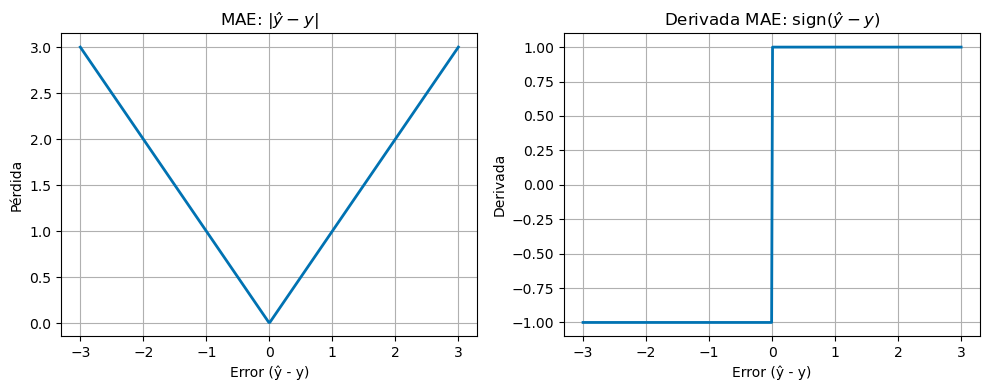

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo general
plt.style.use('seaborn-v0_8-colorblind')

def plot_loss_and_derivative(x, loss, derivative, title_loss, title_deriv, xlabel='ŷ'):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    
    axs[0].plot(x, loss, lw=2)
    axs[0].set_title(title_loss)
    axs[0].set_xlabel(xlabel)
    axs[0].set_ylabel('Pérdida')
    axs[0].grid(True)

    axs[1].plot(x, derivative, lw=2)
    axs[1].set_title(title_deriv)
    axs[1].set_xlabel(xlabel)
    axs[1].set_ylabel('Derivada')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

# ----- MAE -----
x = np.linspace(-3, 3, 400)
mae = np.abs(x)
dmae = np.sign(x)
plot_loss_and_derivative(x, mae, dmae,
                         'MAE: $|ŷ - y|$', 
                         'Derivada MAE: $\mathrm{sign}(ŷ - y)$',
                         xlabel='Error (ŷ - y)')

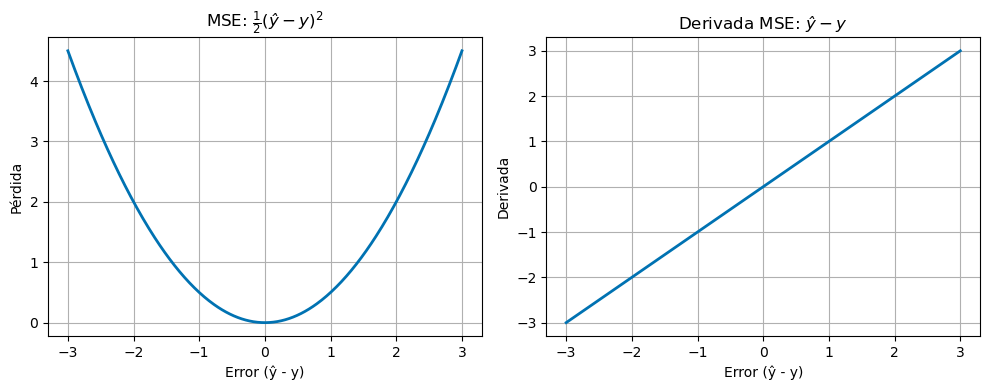

In [42]:
# ----- MSE -----
mse = 0.5 * x**2
dmse = x
plot_loss_and_derivative(x, mse, dmse,
                         'MSE: $\\frac{1}{2}(ŷ - y)^2$', 
                         'Derivada MSE: $ŷ - y$',
                         xlabel='Error (ŷ - y)')

C:\Users\Flavio\AppData\Local\Temp\ipykernel_39576\3382808780.py:2: RuntimeWarning: invalid value encountered in log
  ce = -np.log(x)  # y_k = 1


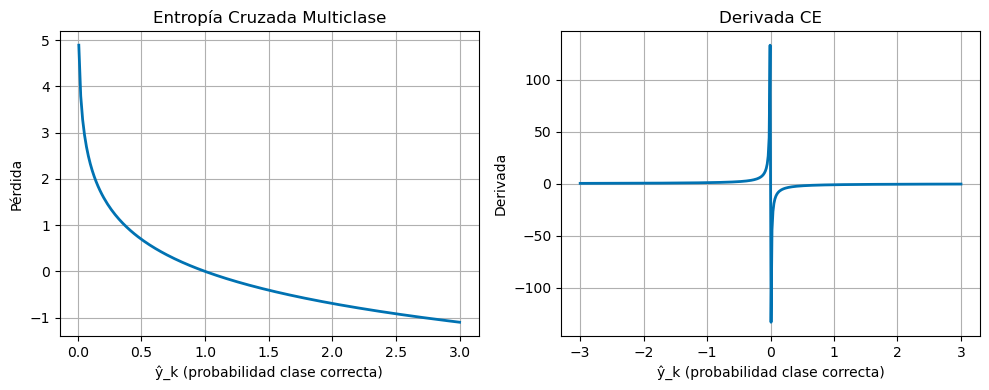

In [43]:
# ----- Cross-Entropy Multiclase -----
ce = -np.log(x)  # y_k = 1
dce = -1 / x
plot_loss_and_derivative(x, ce, dce,
                         'Entropía Cruzada Multiclase', 
                         'Derivada CE',
                         xlabel='ŷ_k (probabilidad clase correcta)')

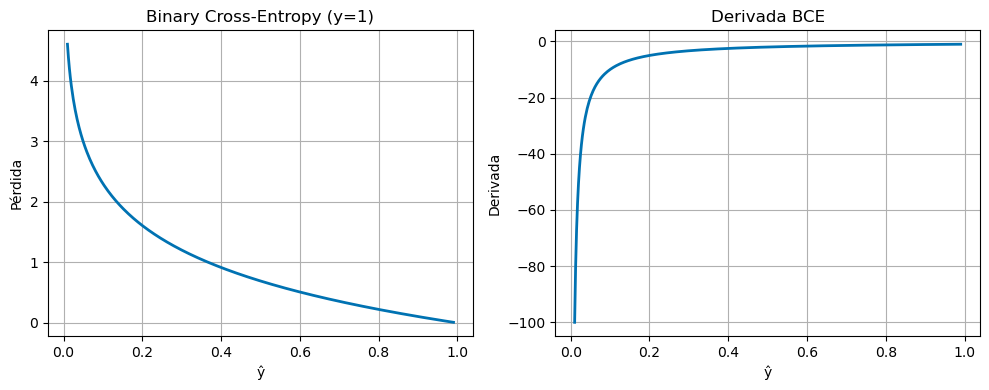

In [44]:
# ----- Binary Cross-Entropy -----
x = np.linspace(0.01, 0.99, 400)
y = 1
bce = - (y * np.log(x) + (1 - y) * np.log(1 - x))
dbce = - (y / x - (1 - y) / (1 - x))
plot_loss_and_derivative(x, bce, dbce,
                         'Binary Cross-Entropy (y=1)', 
                         'Derivada BCE',
                         xlabel='ŷ')

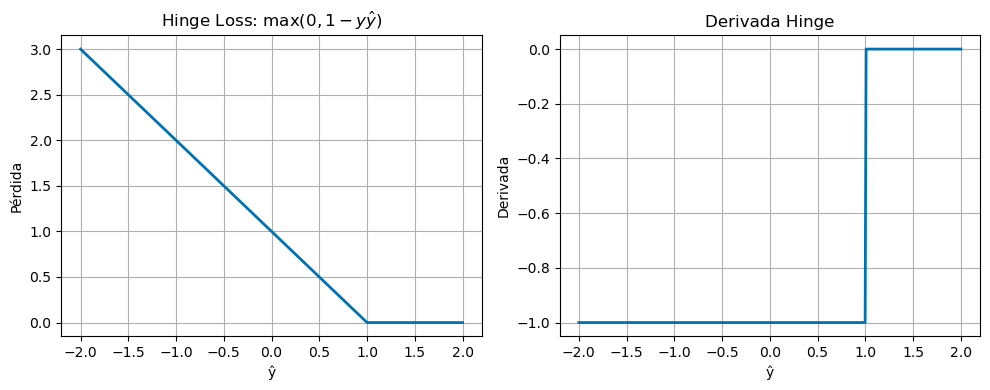

In [45]:
# ----- Hinge Loss -----
x_svm = np.linspace(-2, 2, 400)
y_svm = 1
hinge = np.maximum(0, 1 - y_svm * x_svm)
dhinge = np.where(1 - y_svm * x_svm > 0, -y_svm, 0)
plot_loss_and_derivative(x_svm, hinge, dhinge,
                         'Hinge Loss: $\\max(0, 1 - y\\hat{y})$', 
                         'Derivada Hinge',
                         xlabel='ŷ')

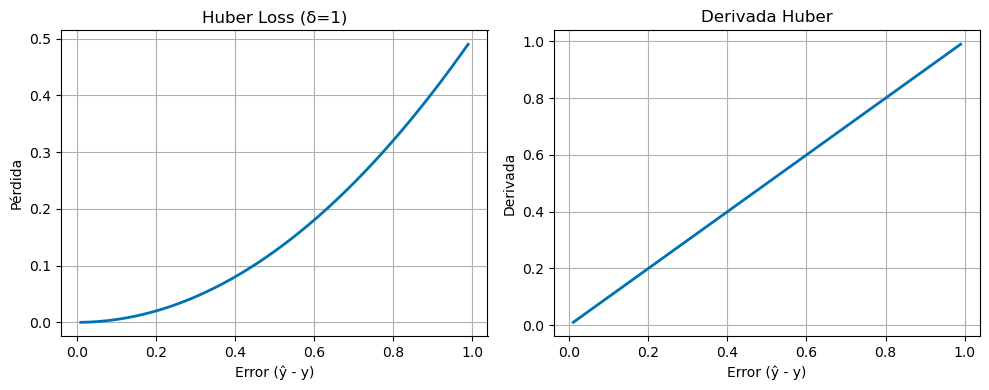

In [46]:
# ----- Huber -----
delta = 1.0
huber = np.where(np.abs(x) <= delta,
                 0.5 * x**2,
                 delta * (np.abs(x) - 0.5 * delta))
dhuber = np.where(np.abs(x) <= delta,
                  x,
                  delta * np.sign(x))
plot_loss_and_derivative(x, huber, dhuber,
                         'Huber Loss (δ=1)', 
                         'Derivada Huber',
                         xlabel='Error (ŷ - y)')

## Funciones de Regularización: L2 vs L1


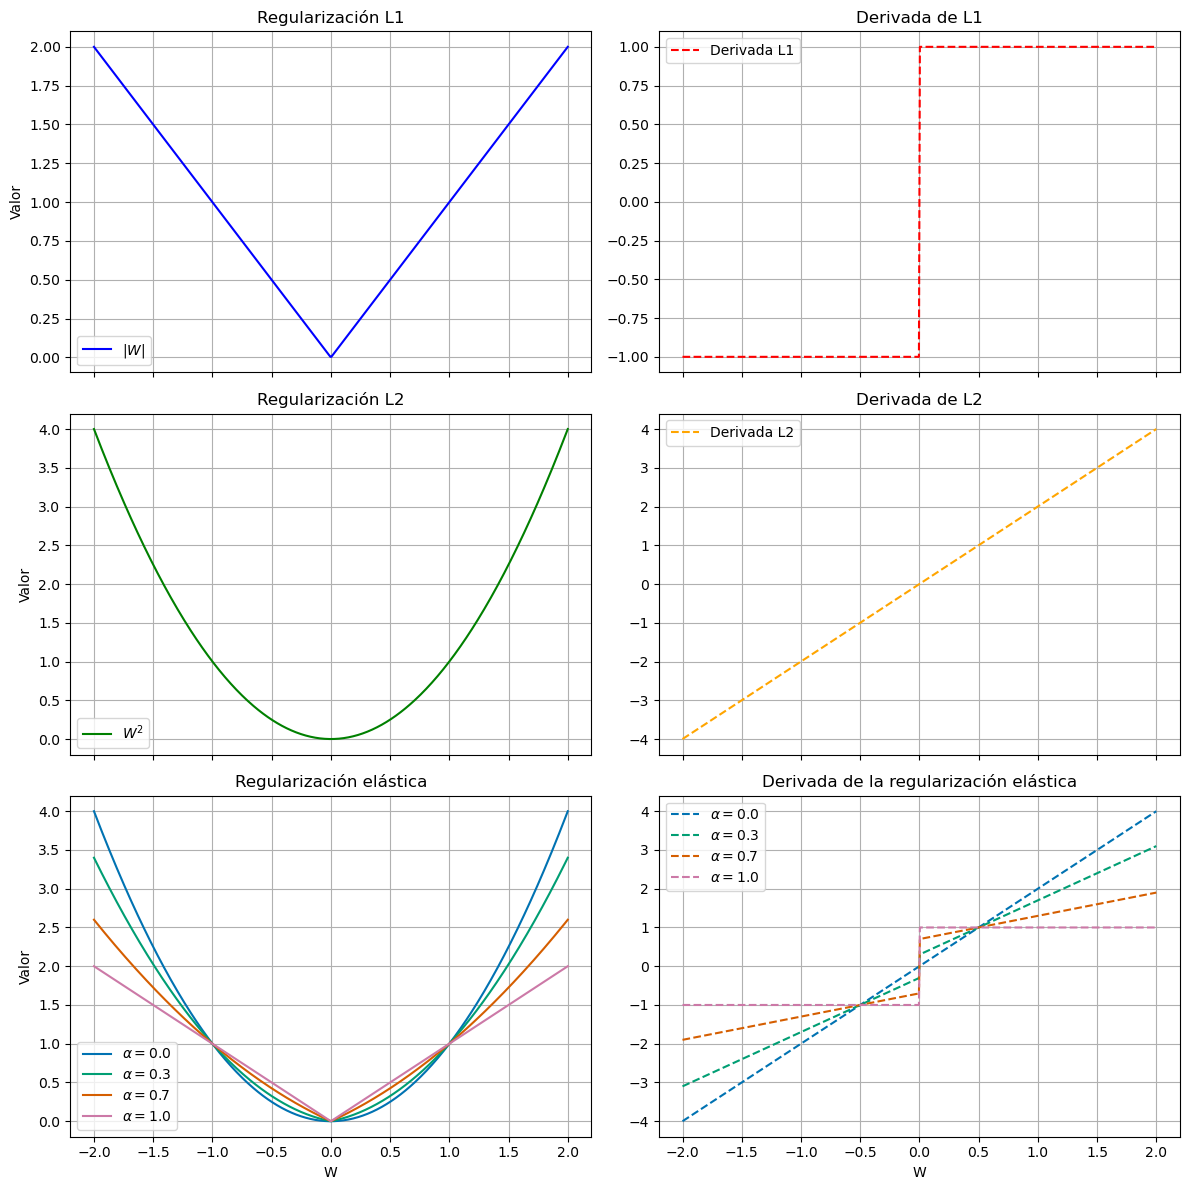

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Vector de pesos W
W = np.linspace(-2, 2, 500)

# Regularización L1
L1 = np.abs(W)
dL1 = np.sign(W)

# Regularización L2
L2 = W**2
dL2 = 2 * W

# Regularización elástica para diferentes valores de λ
alphas = [0.0, 0.3, 0.7, 1.0]
elastic_losses = [l * np.abs(W) + (1 - l) * W**2 for l in alphas]
elastic_derivs = [l * np.sign(W) + (1 - l) * 2 * W for l in alphas]

# Crear figura con 3 filas y 2 columnas
fig, axs = plt.subplots(3, 2, figsize=(12, 12), sharex=True)

# --- L1 ---
axs[0, 0].plot(W, L1, label='$|W|$', color='blue')
axs[0, 0].set_title("Regularización L1")
axs[0, 0].set_ylabel("Valor")
axs[0, 0].legend()
axs[0, 0].grid(True)

axs[0, 1].plot(W, dL1, label='Derivada L1', color='red', linestyle='--')
axs[0, 1].set_title("Derivada de L1")
axs[0, 1].legend()
axs[0, 1].grid(True)

# --- L2 ---
axs[1, 0].plot(W, L2, label='$W^2$', color='green')
axs[1, 0].set_title("Regularización L2")
axs[1, 0].set_ylabel("Valor")
axs[1, 0].legend()
axs[1, 0].grid(True)

axs[1, 1].plot(W, dL2, label='Derivada L2', color='orange', linestyle='--')
axs[1, 1].set_title("Derivada de L2")
axs[1, 1].legend()
axs[1, 1].grid(True)

# --- Elástica ---
for i, alpha in enumerate(alphas):
    axs[2, 0].plot(W, elastic_losses[i], label=f"$\\alpha={alpha}$")
    axs[2, 1].plot(W, elastic_derivs[i], linestyle='--', label=f"$\\alpha={alpha}$")

axs[2, 0].set_title("Regularización elástica")
axs[2, 0].set_ylabel("Valor")
axs[2, 0].legend()
axs[2, 0].grid(True)

axs[2, 1].set_title("Derivada de la regularización elástica")
axs[2, 1].legend()
axs[2, 1].grid(True)

# Eje común X
for ax in axs[2, :]:
    ax.set_xlabel("W")

plt.tight_layout()
plt.show()


---

# Optimizadores

### Optimizadores incluidos:

| Optimizador | Características | Parámetros clave |
|-------------|------------------|-------------------|
| **SGD** (Gradiente Descendente Estocástico) | Pasos constantes, simple | $ \eta $ tasa de aprendizaje |
| **Momentum** | Acumula impulso para suavizar y acelerar | $ \eta $, $ \gamma $: coeficiente de momentum |
| **NAG** (Nesterov Accelerated Gradient) | Mira hacia adelante para predecir mejor | $ \eta $, $ \gamma $ |
| **AdaGrad** | Adapta la tasa de aprendizaje por parámetro | $ \eta $, $ \epsilon $ |
| **RMSprop** | Promedia gradientes cuadrados para escalado adaptativo | $ \eta $, $ \gamma $, $ \epsilon $ |
| **Adam** | Combina Momentum y RMSprop | $ \eta $, $ \beta_1 $, $ \beta_2 $, $ \epsilon $ |
| **AdamW** | Variante de Adam con regularización desacoplada | Igual que Adam + $ \lambda $ |


In [48]:
import numpy as np
import matplotlib.pyplot as plt

In [49]:
# Optimizadores
def sgd(x0, lr, steps):
    x, path = x0, [x0]
    for _ in range(steps):
        x -= lr * grad(x)
        path.append(x)
    return path

def momentum(x0, lr, gamma, steps):
    x, v, path = x0, 0, [x0]
    for _ in range(steps):
        v = gamma * v + lr * grad(x)
        x -= v
        path.append(x)
    return path

def nag(x0, lr, gamma, steps):
    x, v, path = x0, 0, [x0]
    for _ in range(steps):
        g = grad(x - gamma * v)
        v = gamma * v + lr * g
        x -= v
        path.append(x)
    return path

def adagrad(x0, lr, epsilon, steps):
    x, G, path = x0, 0, [x0]
    for _ in range(steps):
        g = grad(x)
        G += g**2
        x -= (lr / (np.sqrt(G) + epsilon)) * g
        path.append(x)
    return path

def rmsprop(x0, lr, gamma, epsilon, steps):
    x, E_g2, path = x0, 0, [x0]
    for _ in range(steps):
        g = grad(x)
        E_g2 = gamma * E_g2 + (1 - gamma) * g**2
        x -= (lr / (np.sqrt(E_g2) + epsilon)) * g
        path.append(x)
    return path

def adam(x0, lr, beta1, beta2, epsilon, steps):
    x, m, v, path = x0, 0, 0, [x0]
    for t in range(1, steps + 1):
        g = grad(x)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        x -= lr * m_hat / (np.sqrt(v_hat) + epsilon)
        path.append(x)
    return path

def adamw(x0, lr, beta1, beta2, epsilon, lambda_, steps):
    x, m, v, path = x0, 0, 0, [x0]
    for t in range(1, steps + 1):
        g = grad(x)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        x -= lr * m_hat / (np.sqrt(v_hat) + epsilon) + lr * lambda_ * x
        path.append(x)
    return path

### Comportamiento de diferentes optimizadores al minimizar una función de pérdida cuadrática simple:  
$$
\mathcal{L}(x) = (x - 3)^2
$$
donde el mínimo global está en $ x = 3 $.


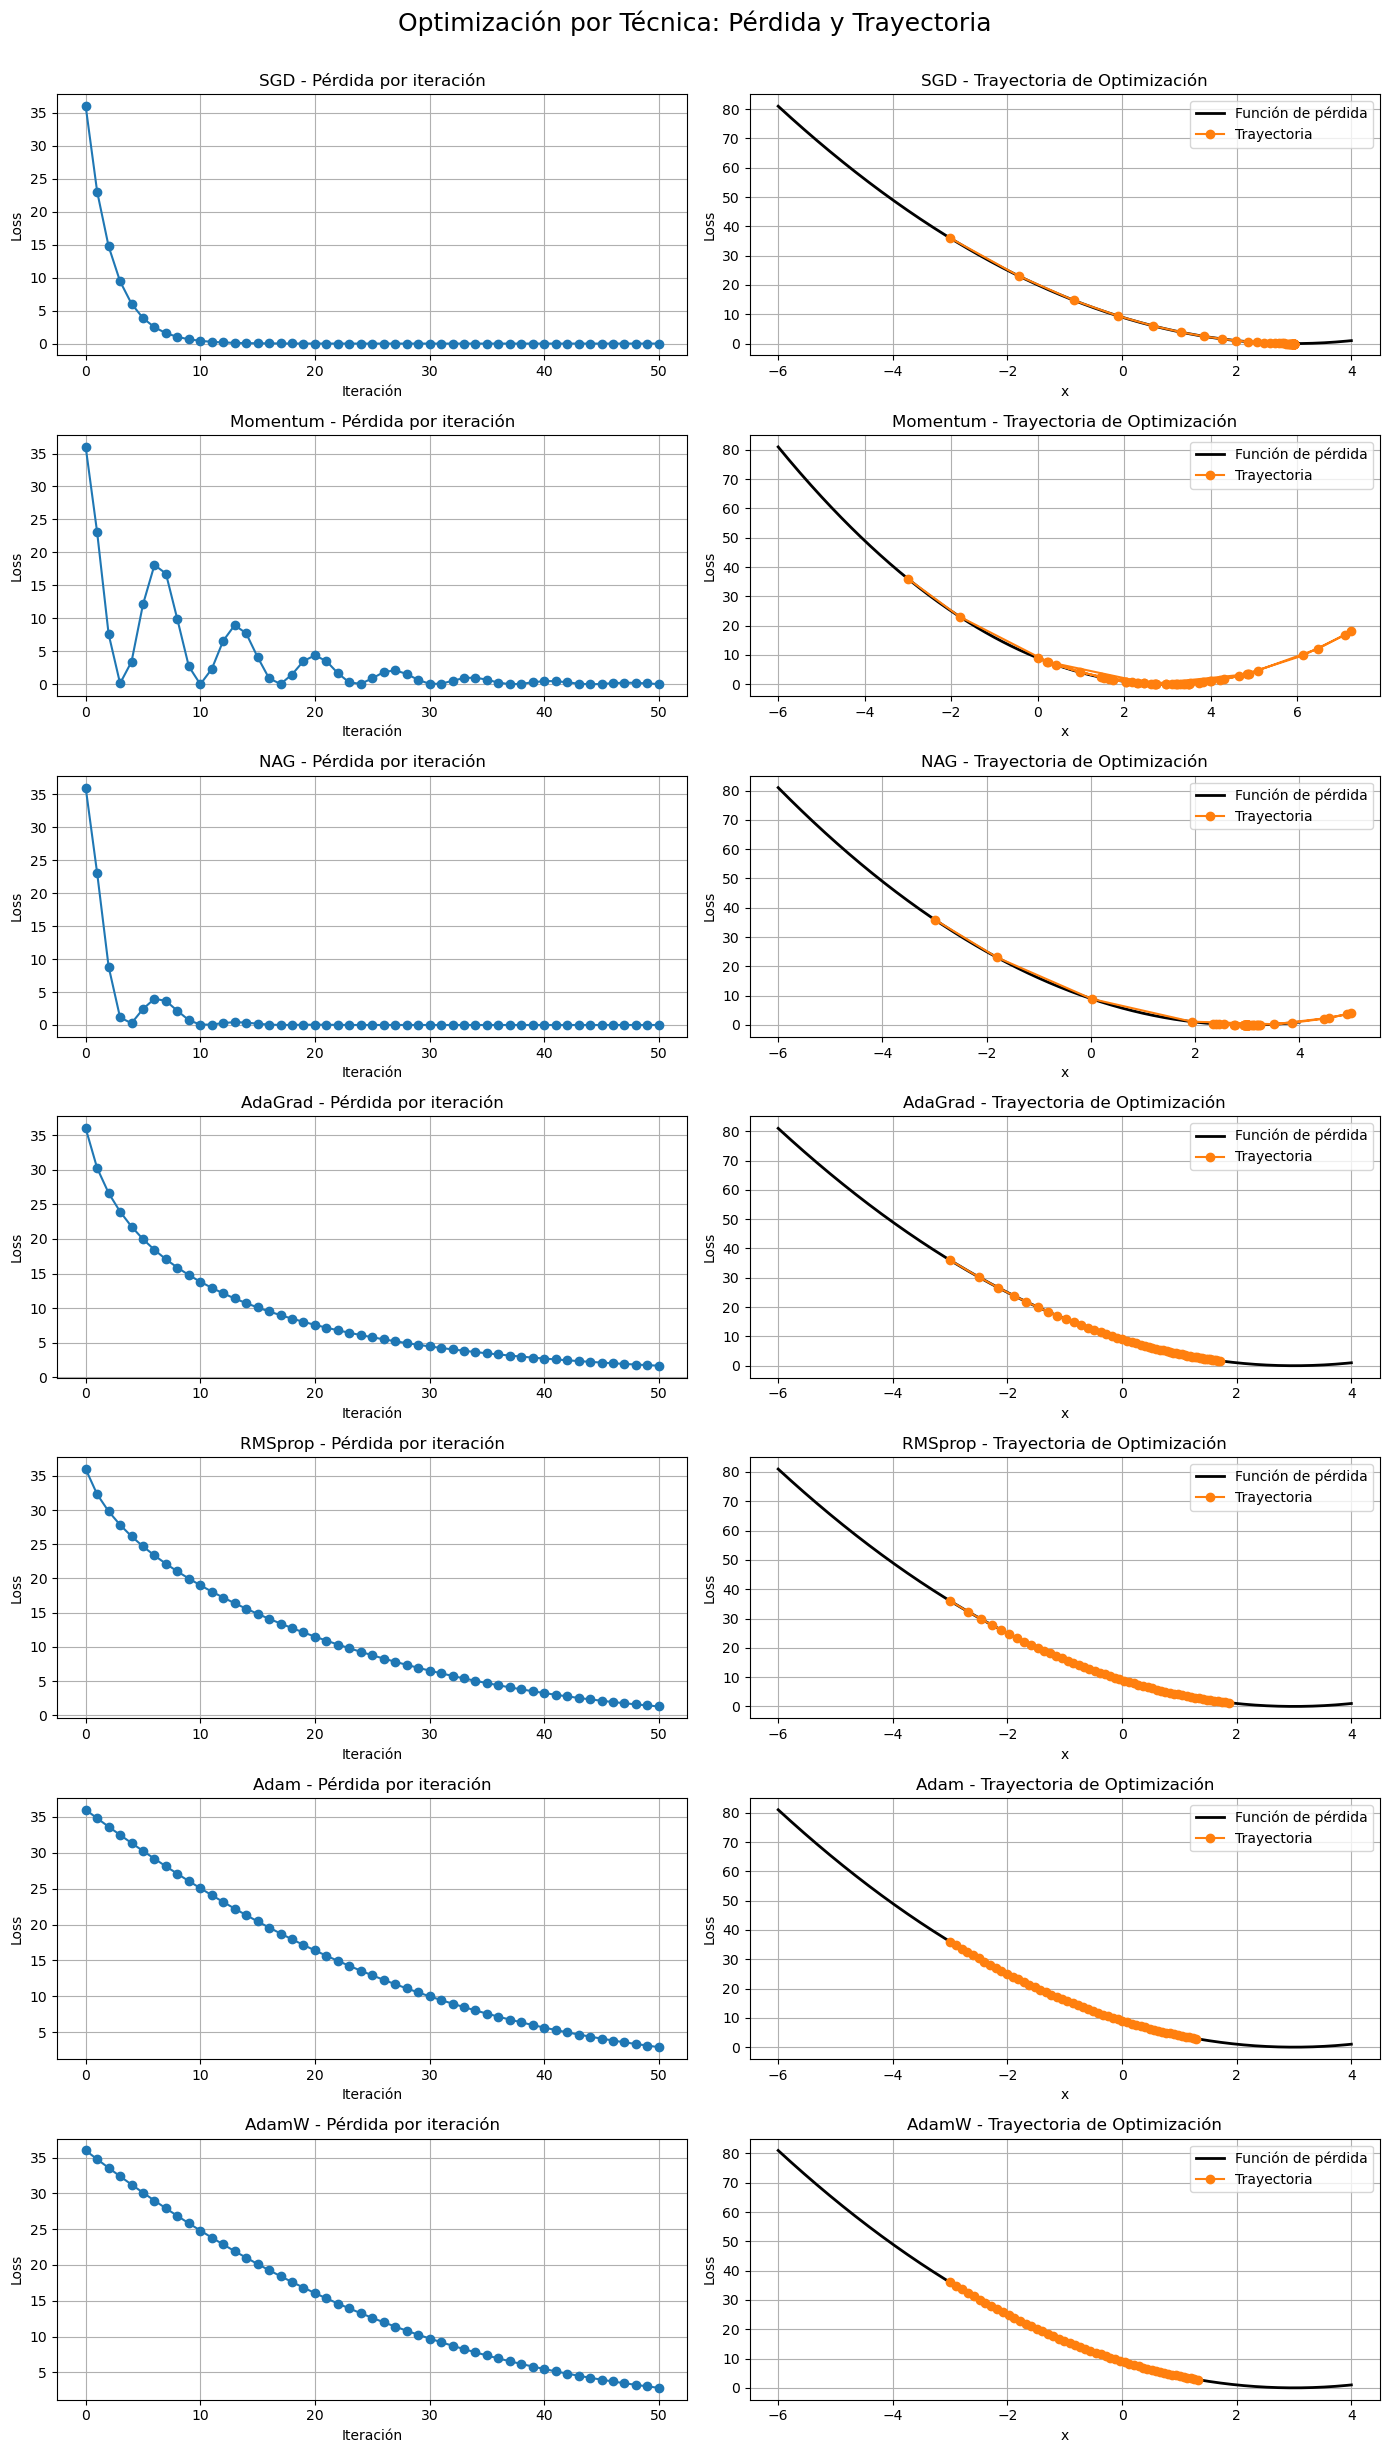

In [50]:
# Función de pérdida y su gradiente (mínimo en x = 3)
def loss(x):
    return (x - 3) ** 2

def grad(x):
    return 2 * (x - 3)

# Parámetros generales
x0 = -3
steps = 50

# Ejecutar trayectorias
paths = {
    "SGD": sgd(x0, lr=0.1, steps=steps),
    "Momentum": momentum(x0, lr=0.1, gamma=0.9, steps=steps),
    "NAG": nag(x0, lr=0.1, gamma=0.9, steps=steps),
    "AdaGrad": adagrad(x0, lr=0.5, epsilon=1e-8, steps=steps),
    "RMSprop": rmsprop(x0, lr=0.1, gamma=0.9, epsilon=1e-8, steps=steps),
    "Adam": adam(x0, lr=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8, steps=steps),
    "AdamW": adamw(x0, lr=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8, lambda_=0.01, steps=steps),
}

# Mostrar curvas individuales de pérdida
x_vals = np.linspace(-6, 6, 400)
y_vals = loss(x_vals)


fig, axs = plt.subplots(nrows=7, ncols=2, figsize=(14, 24))
x_vals = np.linspace(-6, 4, 400)
y_vals = loss(x_vals)

for i, (name, path) in enumerate(paths.items()):
    # Columna izquierda: curva de pérdida
    ax_loss = axs[i, 0]
    losses = [loss(x) for x in path]
    ax_loss.plot(losses, marker='o', color='tab:blue')
    ax_loss.set_title(f"{name} - Pérdida por iteración")
    ax_loss.set_xlabel("Iteración")
    ax_loss.set_ylabel("Loss")
    ax_loss.grid(True)

    # Columna derecha: trayectoria sobre la función
    ax_traj = axs[i, 1]
    ax_traj.plot(x_vals, y_vals, label="Función de pérdida", color="black", linewidth=2)
    ax_traj.plot(path, [loss(x) for x in path], marker='o', label="Trayectoria", color='tab:orange')
    ax_traj.set_title(f"{name} - Trayectoria de Optimización")
    ax_traj.set_xlabel("x")
    ax_traj.set_ylabel("Loss")
    ax_traj.legend()
    ax_traj.grid(True)

plt.tight_layout()
plt.suptitle("Optimización por Técnica: Pérdida y Trayectoria", fontsize=18, y=1.02)
plt.show()




### Comportamiento de diferentes optimizadores al minimizar una función de pérdida cuadrática simple:  
$$
\mathcal{L}(x) = sin(3x)cos(2x) + x^2
$$
donde el mínimo global está en $ x = 0 $.

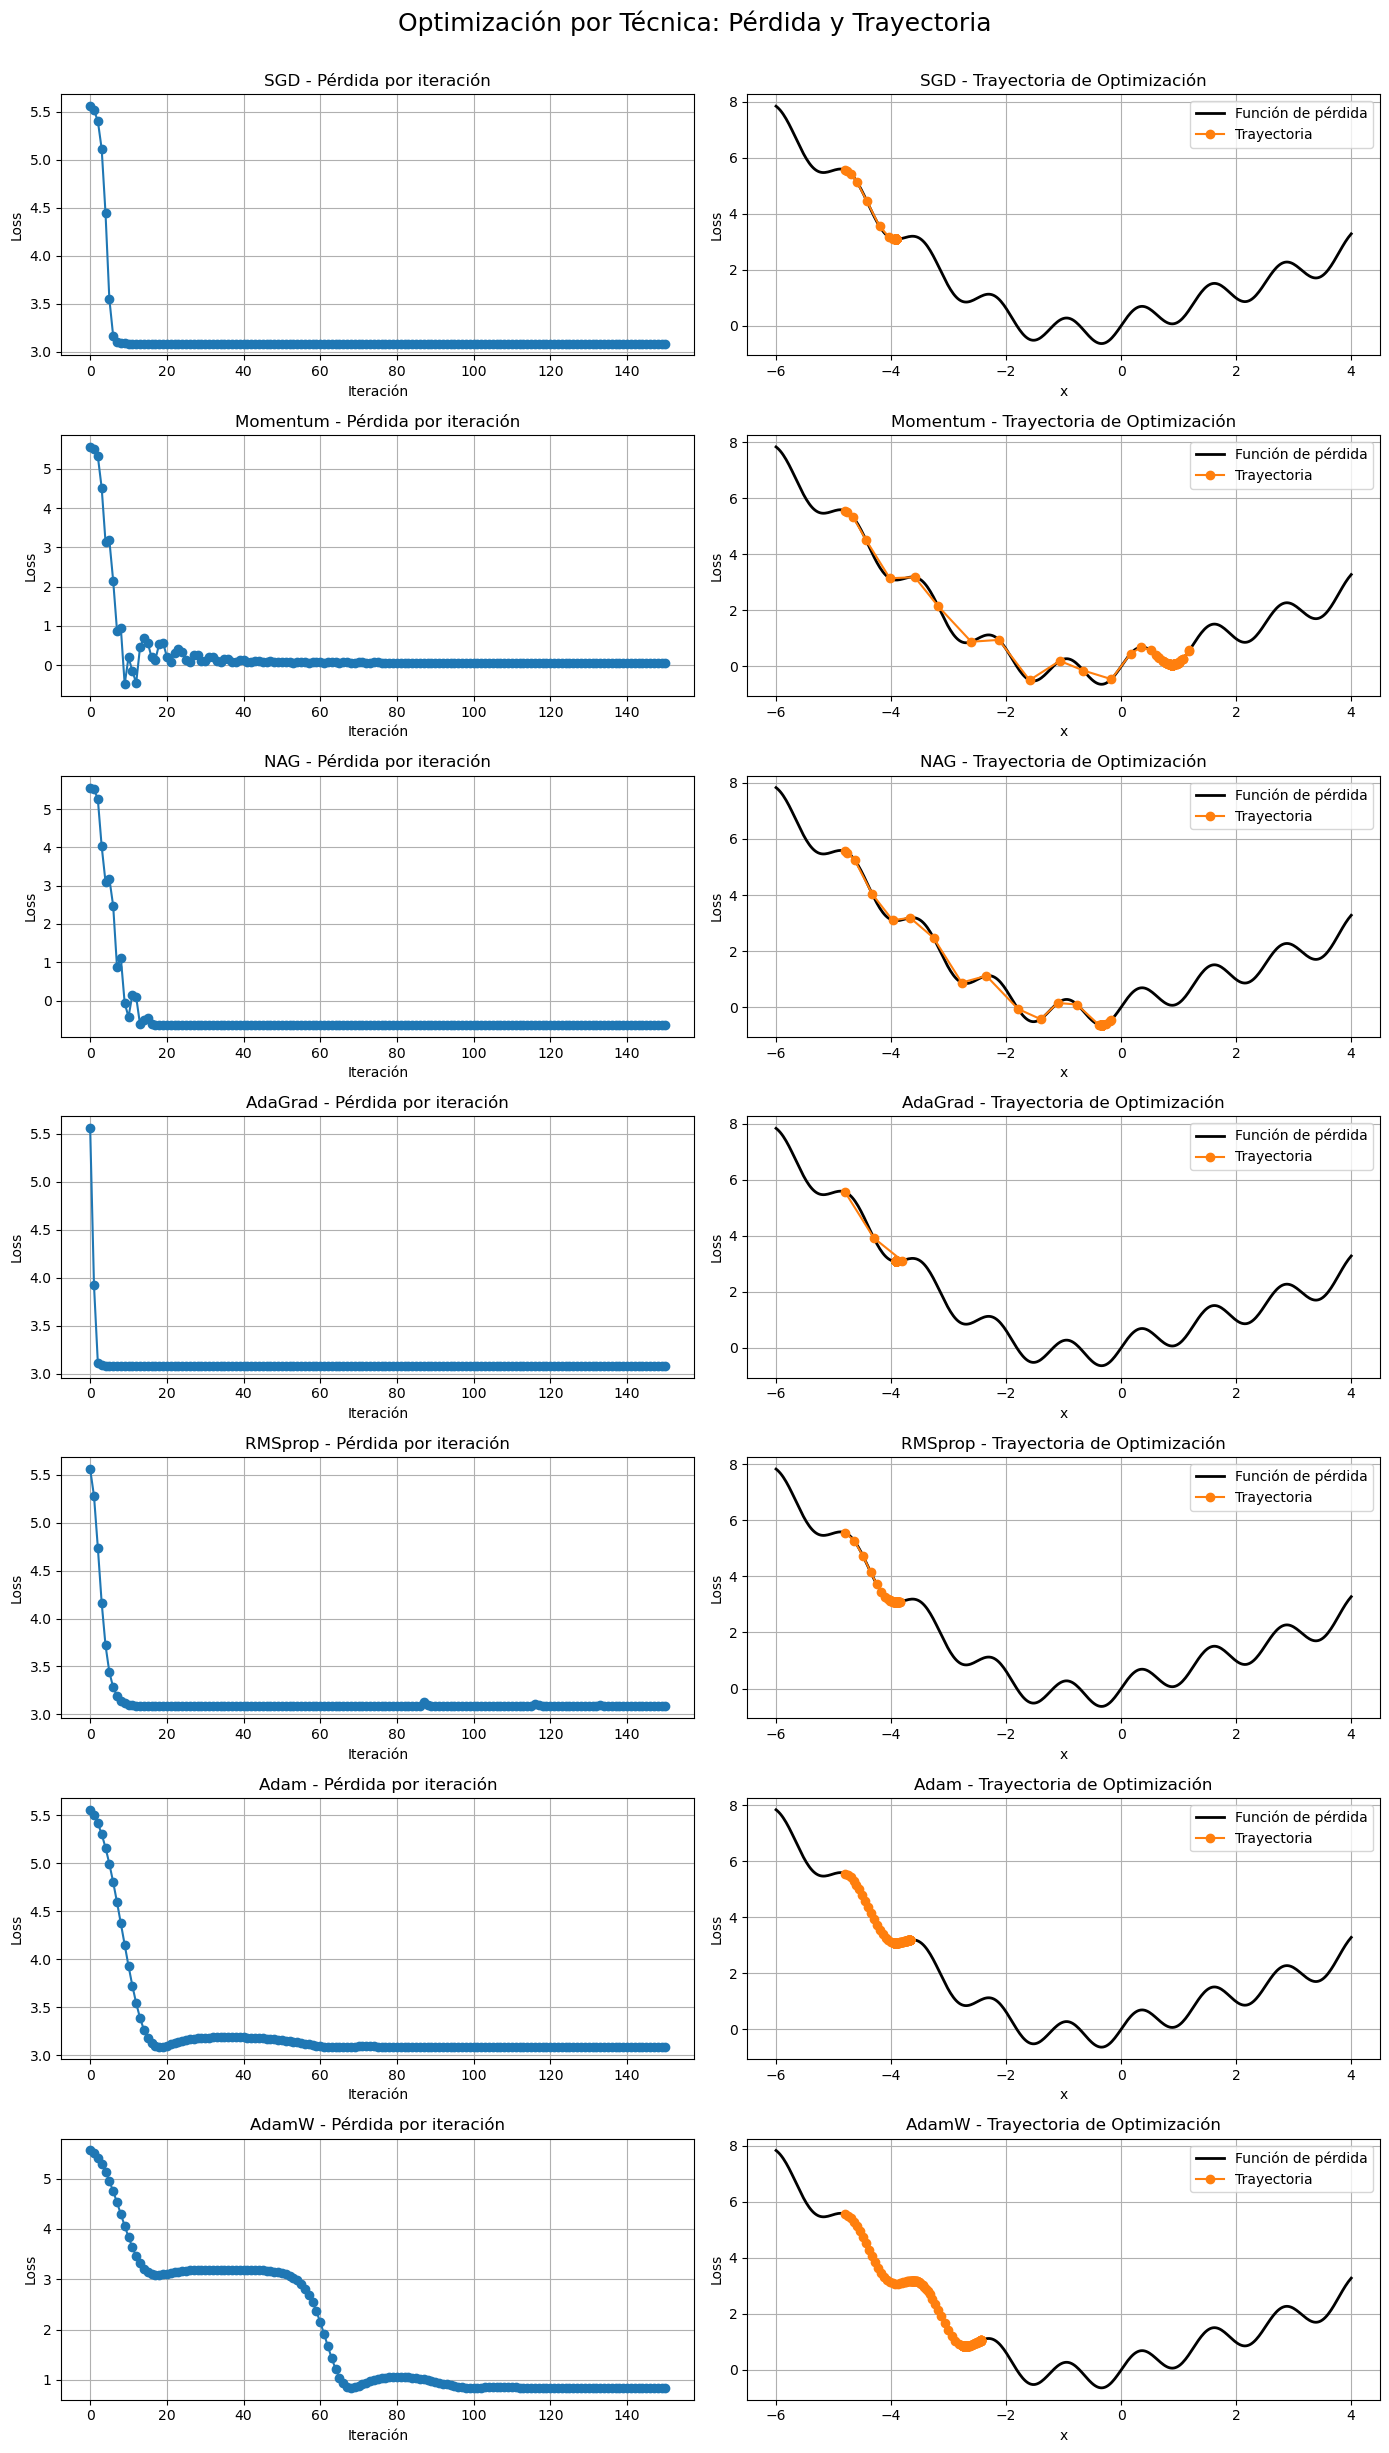

In [51]:
# Función no convexa y su derivada
def loss(x):
    return np.sin(3 * x) * np.cos(2 * x) + 0.2 * x ** 2

def grad(x):
    return 3 * np.cos(3 * x) * np.cos(2 * x) - 2 * np.sin(3 * x) * np.sin(2 * x) + 0.4 * x


# Parámetros generales
x0 = -4.8  # Elegido lejos del mínimo global para ilustrar problemas con mínimos locales
steps = 150

# Ejecutar trayectorias
paths = {
    "SGD": sgd(x0, lr=0.05, steps=steps),
    "Momentum": momentum(x0, lr=0.05, gamma=0.9, steps=steps),
    "NAG": nag(x0, lr=0.05, gamma=0.9, steps=steps),
    "AdaGrad": adagrad(x0, lr=0.5, epsilon=1e-8, steps=steps),
    "RMSprop": rmsprop(x0, lr=0.05, gamma=0.9, epsilon=1e-8, steps=steps),
    "Adam": adam(x0, lr=0.05, beta1=0.9, beta2=0.999, epsilon=1e-8, steps=steps),
    "AdamW": adamw(x0, lr=0.05, beta1=0.9, beta2=0.999, epsilon=1e-8, lambda_=0.01, steps=steps),
}

# Mostrar curvas individuales de pérdida
x_vals = np.linspace(-6, 4, 400)
y_vals = loss(x_vals)

fig, axs = plt.subplots(nrows=7, ncols=2, figsize=(14, 24))
x_vals = np.linspace(-6, 4, 400)
y_vals = loss(x_vals)

for i, (name, path) in enumerate(paths.items()):
    # Columna izquierda: curva de pérdida
    ax_loss = axs[i, 0]
    losses = [loss(x) for x in path]
    ax_loss.plot(losses, marker='o', color='tab:blue')
    ax_loss.set_title(f"{name} - Pérdida por iteración")
    ax_loss.set_xlabel("Iteración")
    ax_loss.set_ylabel("Loss")
    ax_loss.grid(True)

    # Columna derecha: trayectoria sobre la función
    ax_traj = axs[i, 1]
    ax_traj.plot(x_vals, y_vals, label="Función de pérdida", color="black", linewidth=2)
    ax_traj.plot(path, [loss(x) for x in path], marker='o', label="Trayectoria", color='tab:orange')
    ax_traj.set_title(f"{name} - Trayectoria de Optimización")
    ax_traj.set_xlabel("x")
    ax_traj.set_ylabel("Loss")
    ax_traj.legend()
    ax_traj.grid(True)

plt.tight_layout()
plt.suptitle("Optimización por Técnica: Pérdida y Trayectoria", fontsize=18, y=1.02)
plt.show()



# Tasa de aprendizaje $\eta$

Sea la función convexa:

$$
\mathcal{L}(\theta) = (\theta - 3)^2
$$

El algoritmo de descenso por gradiente actualiza el parámetro según:

$$
\theta_{t+1} = \theta_t - \eta \cdot \nabla_\theta \mathcal{L}(\theta_t)
$$

Donde:

$$
\nabla_\theta \mathcal{L}(\theta_t) = 2(\theta_t - 3)
$$

**Efecto de la tasa de aprendizaje $\eta$:**

- **$\eta$ muy pequeño**: convergencia lenta pero estable.
- **$\eta$ moderado (óptimo)**: rápida convergencia al mínimo global.
- **$\eta$ grande**: puede causar oscilaciones o incluso divergencia.

En este experimento:

- Con $\eta = 0.001, \ 0.01$ y $0.1$ se observa convergencia suave.
- Con $\eta = 0.5$ la convergencia es rápida.
- Con $\eta = 0.8$ hay oscilaciones suaves.
- Con $\eta = 1.01$ se produce inestabilidad y posible divergencia.

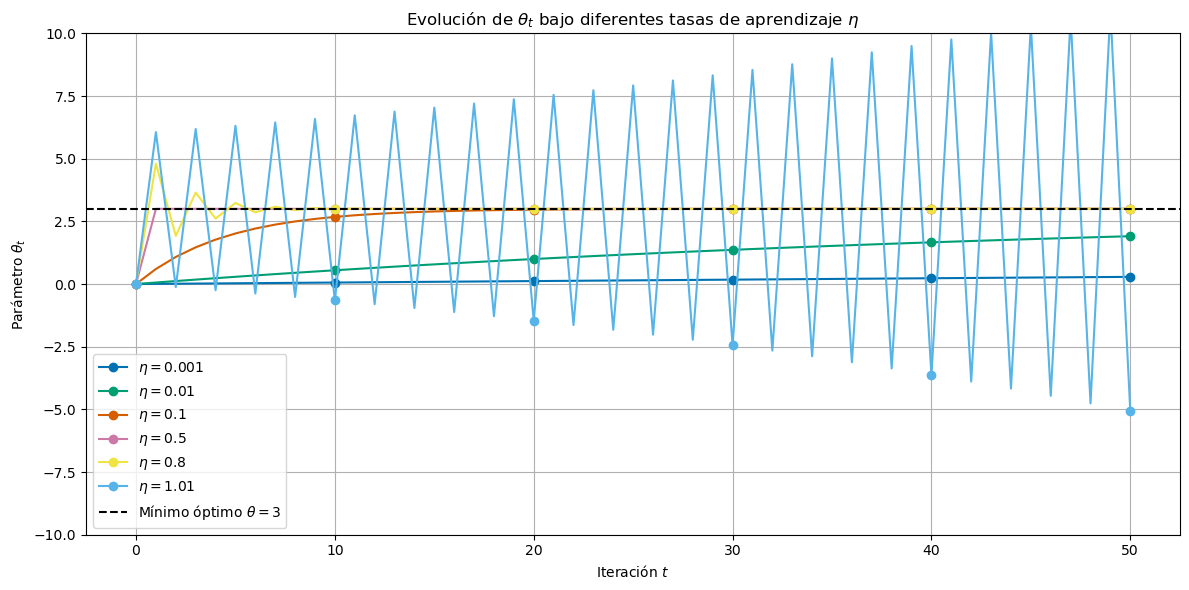

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Función de pérdida
def loss(theta):
    return (theta - 3)**2

# Gradiente
def grad(theta):
    return 2 * (theta - 3)

# Descenso por gradiente
def gd_opt(theta0, eta, steps=50):
    theta = theta0
    trajectory = [theta]
    for _ in range(steps):
        g_t = grad(theta)
        theta = theta - eta * g_t
        trajectory.append(theta)
    return trajectory

# Diferentes tasas de aprendizaje a comparar
etas = [0.001, 0.01, 0.1, 0.5, 0.8, 1.01]
theta0 = 0.0
steps = 50

# Trajectorias
plt.figure(figsize=(12, 6))
for eta in etas:
    path = gd_opt(theta0, eta, steps)
    path = np.array(path)
    plt.plot(path, label=f"$\\eta={eta}$", marker='o', markevery=10)

plt.axhline(y=3, color='black', linestyle='--', label="Mínimo óptimo $\\theta=3$")
plt.ylim(-10, 10)  # Limitar eje Y para mayor claridad
plt.xlabel("Iteración $t$")
plt.ylabel("Parámetro $\\theta_t$")
plt.title("Evolución de $\\theta_t$ bajo diferentes tasas de aprendizaje $\\eta$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Visualización del Descenso por Gradiente variando $\eta$

Se ilustra el comportamiento del algoritmo de **descenso por gradiente** sobre dos funciones:

- **Una función convexa**: $f(x) = (x - 3)^2$, que tiene un único mínimo global.
- **Una función no convexa**: $f(x) = \sin(3x)\cos(2x) + 0.2x^2$, que presenta múltiples mínimos locales.


- **`gradient_descent(...)`**: implementa el algoritmo de descenso por gradiente, partiendo de un valor inicial $x_0$.
- El proceso se detiene si el cambio entre iteraciones es menor a una tolerancia ($\varepsilon = 10^{-5}$), o si se alcanzan $100$ iteraciones máximas.

- **`etas = [0.01, 0.3, 0.8]`**: define tres tasas de aprendizaje $\eta$ para analizar su efecto en el proceso de optimización.


In [53]:
import numpy as np
import matplotlib.pyplot as plt

In [54]:
# Descenso por gradiente con criterio de parada y retorno del número de épocas
def gradient_descent(f, grad, x0, lr, steps=100, tol=1e-5):
    x_vals = [x0]
    y_vals = [f(x0)]
    for i in range(steps):
        x_new = x_vals[-1] - lr * grad(x_vals[-1])
        if abs(x_new - x_vals[-1]) < tol:
            x_vals.append(x_new)
            y_vals.append(f(x_new))
            return x_vals, y_vals, i + 1  # Épocas hasta convergencia
        x_vals.append(x_new)
        y_vals.append(f(x_new))
    return x_vals, y_vals, steps  # No convergió antes de steps

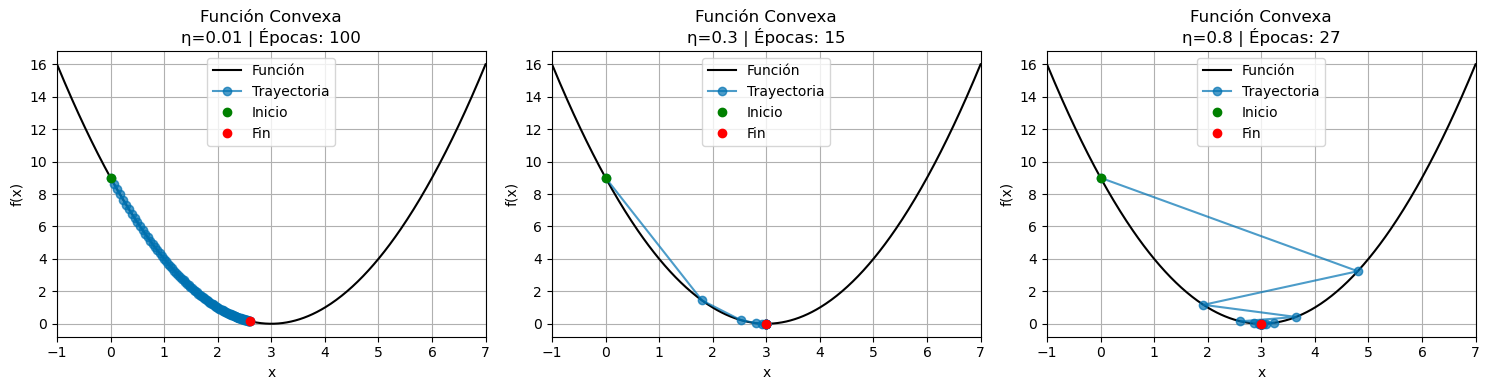

In [55]:
# Función convexa (cuadrática)
def convex(x):
    return (x - 3)**2

def grad_convex(x):
    return 2 * (x - 3)

# Configuración
etas = [0.01, 0.3, 0.8]
title, f, grad, x_range, x0 = 'Función Convexa', convex, grad_convex, np.linspace(-1, 7, 400), 0.0

# Graficar en una sola fila
fig, axes = plt.subplots(1, len(etas), figsize=(15, 4), sharey=False)

for col, eta in enumerate(etas):
    x_vals, y_vals, epocas = gradient_descent(f, grad, x0=x0, lr=eta, steps=100)
    ax = axes[col]
    ax.plot(x_range, f(x_range), 'k-', label='Función')
    ax.plot(x_vals, y_vals, 'o-', label='Trayectoria', alpha=0.7)
    ax.plot(x_vals[0], y_vals[0], 'go', label='Inicio')
    ax.plot(x_vals[-1], y_vals[-1], 'ro', label='Fin')
    ax.set_title(f'{title}\nη={eta} | Épocas: {epocas}')
    ax.grid(True)
    ax.set_xlim(x_range[0], x_range[-1])
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()

plt.tight_layout()
plt.show()


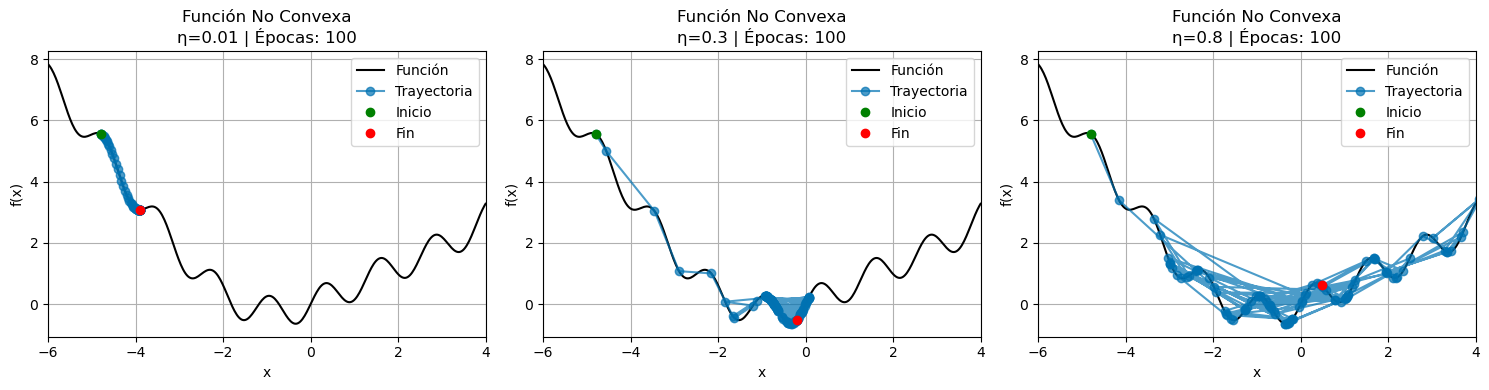

In [56]:
# Función no convexa (multimodal)
def concave(x):
    return np.sin(3 * x) * np.cos(2 * x) + 0.2 * x**2

def grad_concave(x):
    return 3 * np.cos(3 * x) * np.cos(2 * x) - 2 * np.sin(3 * x) * np.sin(2 * x) + 0.4 * x

# Configuración
etas = [0.01, 0.3, 0.8]
title, f, grad, x_range, x0 = 'Función No Convexa', concave, grad_concave, np.linspace(-6, 4, 400), -4.8

# Graficar en una sola fila
fig, axes = plt.subplots(1, len(etas), figsize=(15, 4), sharey=False)

for col, eta in enumerate(etas):
    x_vals, y_vals, epocas = gradient_descent(f, grad, x0=x0, lr=eta, steps=100)
    ax = axes[col]
    ax.plot(x_range, f(x_range), 'k-', label='Función')
    ax.plot(x_vals, y_vals, 'o-', label='Trayectoria', alpha=0.7)
    ax.plot(x_vals[0], y_vals[0], 'go', label='Inicio')
    ax.plot(x_vals[-1], y_vals[-1], 'ro', label='Fin')
    ax.set_title(f'{title}\nη={eta} | Épocas: {epocas}')
    ax.grid(True)
    ax.set_xlim(x_range[0], x_range[-1])
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()

plt.tight_layout()
plt.show()

---
## TECNICAS PARA SELECCIONAR LA TASA DE APRENDIZAJE $\eta$
---

### Escaneo Logarítmico de la Tasa de Aprendizaje

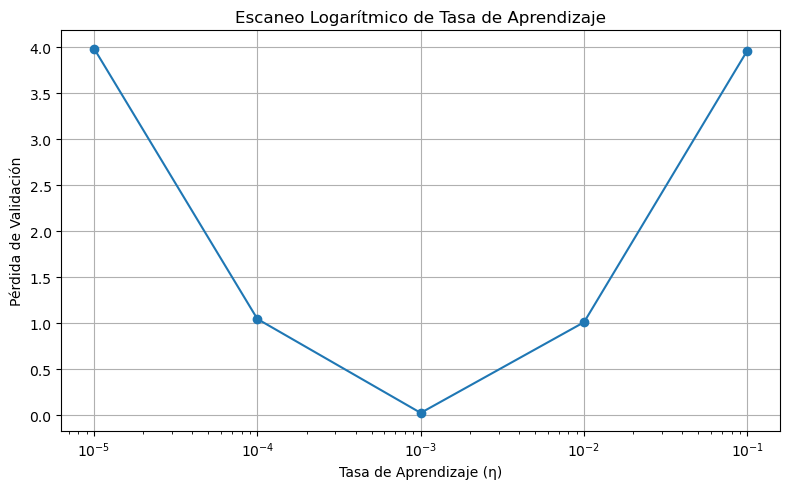

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de tasa de aprendizaje a probar (escala logarítmica)
etas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

# Simular pérdida de validación para cada tasa de aprendizaje
# (En un caso real, se entrenaría un modelo y se calcularía la pérdida en el conjunto de validación)
np.random.seed(42)
true_min = 1e-3
val_losses = [(np.log10(eta) - np.log10(true_min))**2 + np.random.uniform(-0.05, 0.05) for eta in etas]

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(etas, val_losses, marker='o', linestyle='-', color='tab:blue')
plt.xscale('log')
plt.xlabel('Tasa de Aprendizaje (η)')
plt.ylabel('Pérdida de Validación')
plt.title('Escaneo Logarítmico de Tasa de Aprendizaje')
plt.grid(True)
plt.xticks(etas, labels=[f"$10^{{{int(np.log10(e))}}}$" for e in etas])
plt.tight_layout()
plt.show()


### Learning Rate Finder

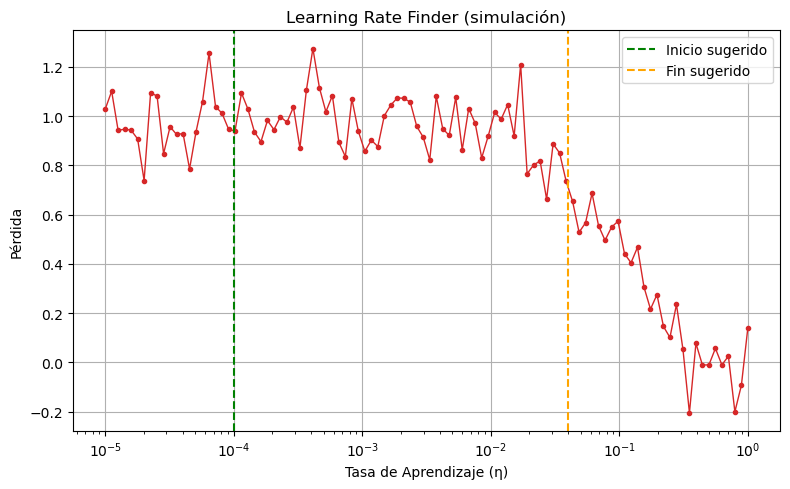

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Función simulada del Learning Rate Finder
def learning_rate_finder():
    etas = np.logspace(-5, 0, 100)  # η desde 1e-5 hasta 1
    loss = np.exp(-etas * 8) + 0.1 * np.random.randn(len(etas))  # pérdida simulada
    return etas, loss

# Obtener datos
etas, losses = learning_rate_finder()

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(etas, losses, color='tab:red', marker='o', markersize=3, linewidth=1)
plt.xscale('log')
plt.xlabel('Tasa de Aprendizaje (η)')
plt.ylabel('Pérdida')
plt.title('Learning Rate Finder (simulación)')
plt.grid(True)

# Anotar un rango razonable donde la pérdida cae rápidamente
plt.axvline(1e-4, color='green', linestyle='--', label='Inicio sugerido')
plt.axvline(4e-2, color='orange', linestyle='--', label='Fin sugerido')
plt.legend()

plt.tight_layout()
plt.show()


### Validación Cruzada para Selección de la Tasa de Aprendizaje


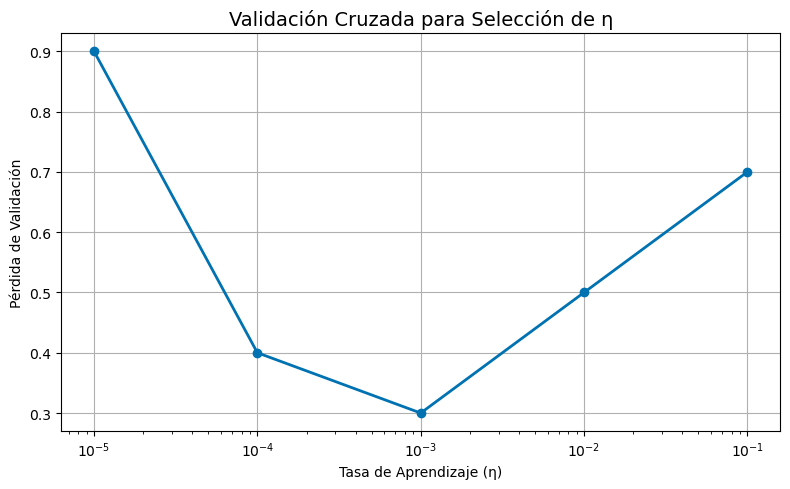

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Datos simulados para validación cruzada
etas_cv = np.logspace(-5, -1, 5)
val_loss = [0.9, 0.4, 0.3, 0.5, 0.7]

# Figura
plt.figure(figsize=(8, 5))
plt.plot(etas_cv, val_loss, marker='o', linewidth=2)
plt.xscale('log')
plt.title("Validación Cruzada para Selección de η", fontsize=14)
plt.xlabel("Tasa de Aprendizaje (η)")
plt.ylabel("Pérdida de Validación")
plt.grid(True)
plt.tight_layout()
plt.show()


### Reducción Programada de la Tasa de Aprendizaje (Step Decay)

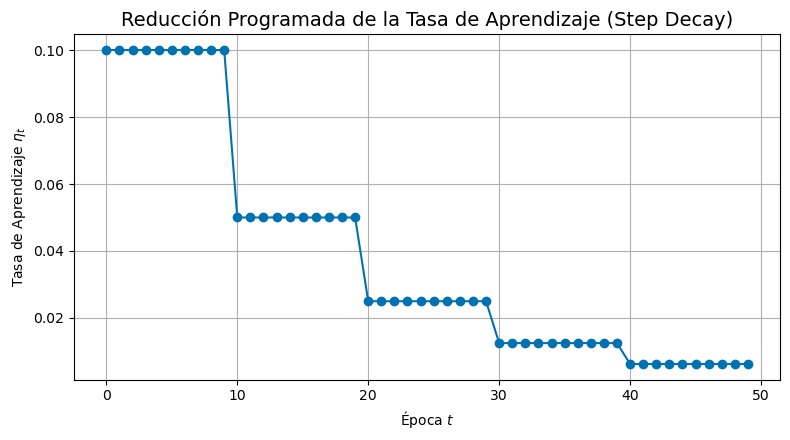

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la fórmula
eta_0 = 0.1       # tasa de aprendizaje inicial
gamma = 0.5       # factor de reducción (< 1)
s = 10            # número de pasos antes de reducir
epochs = 50       # total de épocas

# Cálculo de η_t usando step decay
eta_t = [eta_0 * gamma**(t // s) for t in range(epochs)]

# Graficar
plt.figure(figsize=(8, 4.5))
plt.plot(range(epochs), eta_t, marker='o')
plt.title("Reducción Programada de la Tasa de Aprendizaje (Step Decay)", fontsize=14)
plt.xlabel("Época $t$")
plt.ylabel("Tasa de Aprendizaje $\\eta_t$")
plt.grid(True)
plt.tight_layout()
plt.show()


### Reducción de la Tasa de Aprendizaje Basada en el Desempeño (ReduceLROnPlateau)

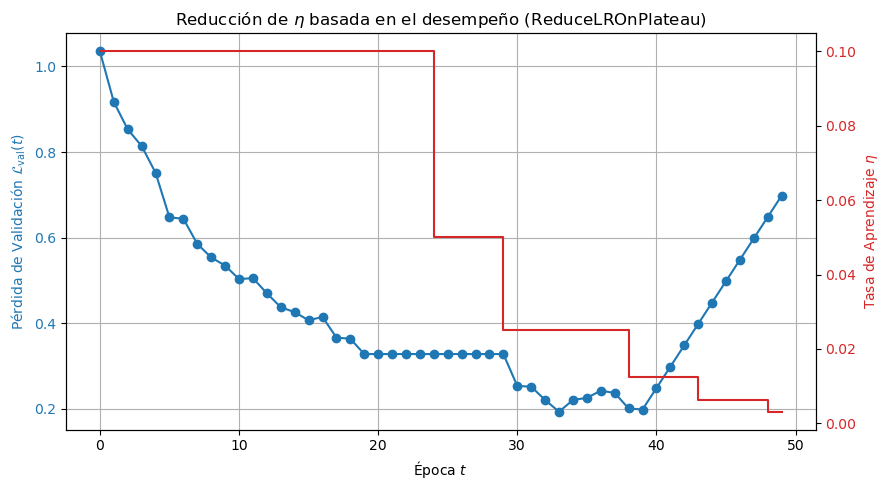

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
eta_0 = 0.1          # tasa de aprendizaje inicial
gamma = 0.5          # factor de reducción
patience = 5         # número de épocas sin mejora
epochs = 50          # total de épocas

# Simulación de pérdida de validación con estancamiento
np.random.seed(0)
val_loss = [1 / (1 + 0.1 * t) + np.random.normal(0, 0.02) for t in range(epochs)]
val_loss[20:30] = [val_loss[19]] * 10  # simula estancamiento
val_loss[40:] = [val_loss[39] + 0.05 * (t - 39) for t in range(40, epochs)]  # simula empeoramiento

# Reducción de la tasa de aprendizaje por desempeño
etas = []
eta = eta_0
best_loss = np.inf
epochs_since_improvement = 0

for t in range(epochs):
    current_loss = val_loss[t]
    if current_loss < best_loss - 1e-4:
        best_loss = current_loss
        epochs_since_improvement = 0
    else:
        epochs_since_improvement += 1

    if epochs_since_improvement >= patience:
        eta *= gamma
        epochs_since_improvement = 0  # reiniciar contador

    etas.append(eta)

# Gráfica
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel('Época $t$')
ax1.set_ylabel('Pérdida de Validación $\\mathcal{L}_\\text{val}(t)$', color=color)
ax1.plot(val_loss, marker='o', label='Pérdida de validación', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Tasa de aprendizaje en segundo eje
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Tasa de Aprendizaje $\\eta$', color=color)
ax2.step(range(epochs), etas, where='post', label='Tasa de aprendizaje', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Reducción de $\\eta$ basada en el desempeño (ReduceLROnPlateau)')
fig.tight_layout()
plt.show()


# Efecto del hiperparámetro $\gamma$ (técnica **Momentum**)

Sea la función de pérdida cuadrática:

$$
\mathcal{L}(\theta) = (\theta - 3)^2
$$

La actualización con **Momentum** se define como:

$$
\begin{aligned}
v_t &\leftarrow \gamma v_{t-1} + \eta \nabla_\theta \mathcal{L}(\theta_t), \quad v_0 = 0 \\
\theta_{t+1} &\leftarrow \theta_t - v_t
\end{aligned}
$$

**Análisis del efecto de $\gamma$:**

- **$\gamma = 0$**: Se comporta como el descenso por gradiente estándar (SGD), sin memoria del pasado.
- **$0 < \gamma < 1$**: Se introduce una inercia que acelera la convergencia en direcciones consistentes del gradiente.
- **$\gamma$ cercano a 1**: Fuerte efecto de memoria. Puede acelerar mucho la convergencia, pero también generar oscilaciones si no se controla adecuadamente.

En este ejemplo, todas las trayectorias convergen al mínimo en $\theta = 3$, pero la velocidad y la suavidad de la convergencia dependen fuertemente de $\gamma$.

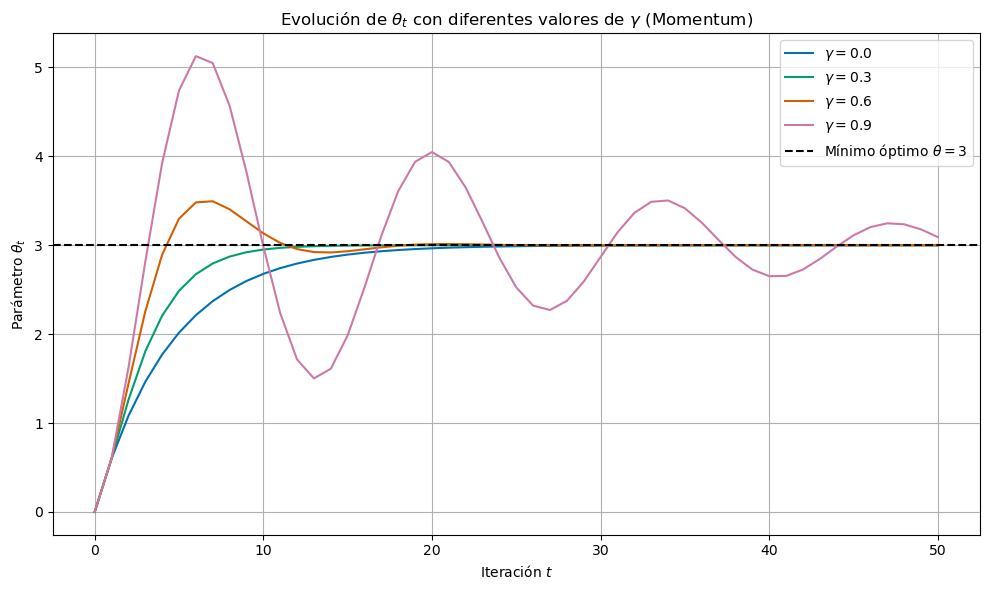

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Función de pérdida: L(θ) = (θ - 3)^2
def loss(theta):
    return (theta - 3)**2

# Gradiente de la función: ∇_θ L(θ) = 2(θ - 3)
def grad(theta):
    return 2 * (theta - 3)

# Optimizador con técnica Momentum
def momentum_opt(theta0, gamma, eta=0.1, steps=50):
    theta = theta0
    v_t = 0.0  # velocidad inicial
    trajectory = [theta]

    for t in range(steps):
        g_t = grad(theta)
        v_t = gamma * v_t + eta * g_t
        theta = theta - v_t
        trajectory.append(theta)

    return trajectory

# Configuraciones de gamma para comparar
gammas = [0.0, 0.3, 0.6, 0.9]

# Simulación
theta0 = 0.0
steps = 50

plt.figure(figsize=(10, 6))
for gamma in gammas:
    path = momentum_opt(theta0, gamma, eta=0.1, steps=steps)
    label = f"$\\gamma={gamma}$"
    plt.plot(path, label=label)

plt.axhline(y=3, color='black', linestyle='--', label="Mínimo óptimo $\\theta = 3$")
plt.xlabel("Iteración $t$")
plt.ylabel("Parámetro $\\theta_t$")
plt.title("Evolución de $\\theta_t$ con diferentes valores de $\\gamma$ (Momentum)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Efecto del parámetro $\rho$ en (técnica **RMSprop**)

Sea la función de pérdida cuadrática:

$$
\mathcal{L}(\theta) = (\theta - 3)^2
$$

La técnica **RMSprop** utiliza una media móvil exponencial del cuadrado de los gradientes:

$$
\begin{aligned}
r_t &\leftarrow \rho r_{t-1} + (1 - \rho) \left( \nabla_\theta \mathcal{L}(\theta_t) \right)^2, \quad r_0 = 0 \\
\theta_{t+1} &\leftarrow \theta_t - \frac{\eta}{\sqrt{r_t} + \varepsilon} \cdot \nabla_\theta \mathcal{L}(\theta_t)
\end{aligned}
$$

**Interpretación del parámetro $\rho$**:

- **$\rho = 0$**: no hay promedio; se comporta como SGD con normalización puntual.
- **$\rho$ bajo (e.g., 0.3)**: adaptación rápida al gradiente actual, pero con más inestabilidad.
- **$\rho$ alto (e.g., 0.9)**: adaptación lenta pero más suave, con memoria larga.

En este ejemplo:

- Todas las trayectorias convergen al mínimo global en $\theta = 3$, pero la **velocidad de convergencia y la suavidad** varían fuertemente con $\rho$.
- $\rho$ alto produce pasos más cortos y estables.
- $\rho$ bajo permite pasos más agresivos pero puede generar oscilaciones o ruido.

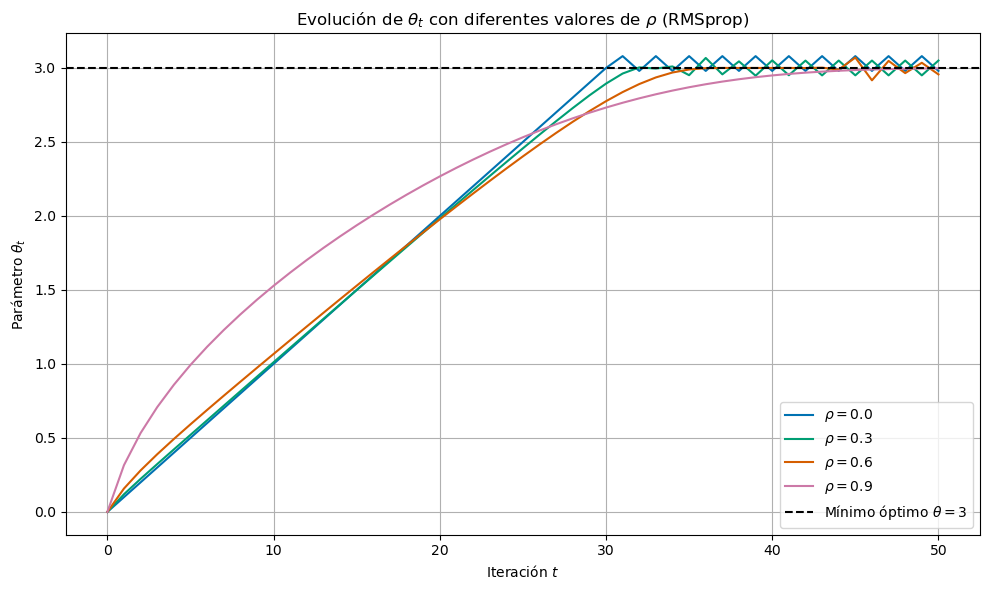

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Función de pérdida: L(θ) = (θ - 3)^2
def loss(theta):
    return (theta - 3)**2

# Gradiente: ∇_θ L(θ) = 2(θ - 3)
def grad(theta):
    return 2 * (theta - 3)

# RMSprop
def rmsprop_opt(theta0, rho, eta=0.1, eps=1e-8, steps=50):
    theta = theta0
    r_t = 0.0
    trajectory = [theta]

    for t in range(1, steps + 1):
        g_t = grad(theta)
        r_t = rho * r_t + (1 - rho) * g_t**2
        theta = theta - eta * g_t / (np.sqrt(r_t) + eps)
        trajectory.append(theta)

    return trajectory

# Configuraciones de rho a comparar
rhos = [0.0, 0.3, 0.6, 0.9]

# Simulación
theta0 = 0.0
steps = 50

plt.figure(figsize=(10, 6))
for rho in rhos:
    path = rmsprop_opt(theta0, rho, eta=0.1, steps=steps)
    label = f"$\\rho={rho}$"
    plt.plot(path, label=label)

plt.axhline(y=3, color='black', linestyle='--', label="Mínimo óptimo $\\theta = 3$")
plt.xlabel("Iteración $t$")
plt.ylabel("Parámetro $\\theta_t$")
plt.title("Evolución de $\\theta_t$ con diferentes valores de $\\rho$ (RMSprop)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Impacto de los hiperparámetros $\beta_1$ y $\beta_2$ (técnica Adam).

Se simulación de la variación del parámetro $\theta_t$ durante la optimización con **Adam**, minimizando la función de pérdida $\mathcal{L}(\theta) = (\theta - 3)^2$.

El algoritmo Adam actualiza los parámetros según:

$$
\begin{aligned}
m_t &\leftarrow \beta_1 m_{t-1} + (1 - \beta_1) \nabla_\theta \mathcal{L}(\theta_t), \quad m_0 = 0 \\
v_t &\leftarrow \beta_2 v_{t-1} + (1 - \beta_2) \left( \nabla_\theta \mathcal{L}(\theta_t) \right)^2, \quad v_0 = 0 \\
\hat{m}_t &\leftarrow \frac{m_t}{1 - \beta_1^t}, \quad
\hat{v}_t \leftarrow \frac{v_t}{1 - \beta_2^t} \\
\theta_{t+1} &\leftarrow \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \varepsilon} \cdot \hat{m}_t
\end{aligned}
$$

**Observaciones**:

- Valores altos de $\beta_1$ y $\beta_2$ suavizan más la actualización.
- Valores bajos responden más rápidamente pero pueden producir oscilaciones.
- El mínimo de la función se alcanza cuando $\theta = 3$ (línea punteada).

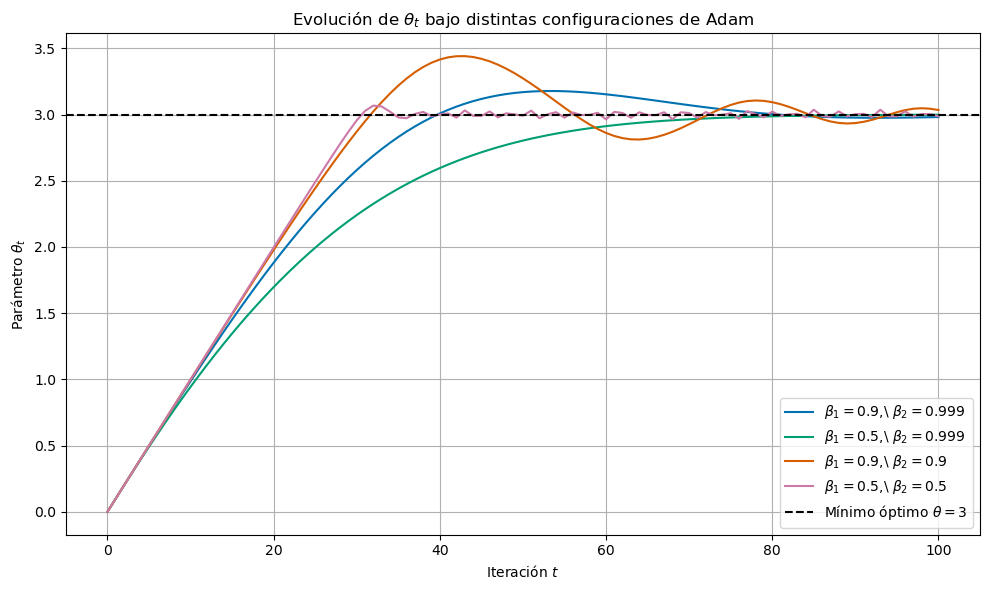

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Función de pérdida: L(θ) = (θ - 3)^2
def loss(theta):
    return (theta - 3)**2

# Gradiente: ∇_θ L(θ)
def grad(theta):
    return 2 * (theta - 3)

# Optimización con Adam usando notación θ
def adam_opt(theta0, beta1, beta2, eta=0.1, eps=1e-8, steps=100):
    theta = theta0
    m_t, v_t = 0, 0
    trajectory = [theta]

    for t in range(1, steps + 1):
        g_t = grad(theta)
        m_t = beta1 * m_t + (1 - beta1) * g_t
        v_t = beta2 * v_t + (1 - beta2) * g_t**2

        m_hat = m_t / (1 - beta1**t)
        v_hat = v_t / (1 - beta2**t)

        theta = theta - eta * m_hat / (np.sqrt(v_hat) + eps)
        trajectory.append(theta)

    return trajectory

# Configuraciones de prueba
configs = [
    (0.9, 0.999),
    (0.5, 0.999),
    (0.9, 0.9),
    (0.5, 0.5)
]

# Simulación
theta0 = 0.0
steps = 100

plt.figure(figsize=(10, 6))
for beta1, beta2 in configs:
    path = adam_opt(theta0, beta1, beta2, eta=0.1, steps=steps)
    label = f"$\\beta_1={beta1}$,\ $\\beta_2={beta2}$"
    plt.plot(path, label=label)

plt.axhline(y=3, color='black', linestyle='--', label="Mínimo óptimo $\\theta=3$")
plt.xlabel("Iteración $t$")
plt.ylabel("Parámetro $\\theta_t$")
plt.title("Evolución de $\\theta_t$ bajo distintas configuraciones de Adam")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# HIPERPARÁMETRO DE REGULARIZACIÓN $\lambda$ 

## Validación Cruzada para Selección de $\lambda$ Óptimo

Este experimento ilustra cómo se selecciona el valor óptimo de $\lambda$ (también llamado `alpha` en `Ridge`) usando **validación cruzada** con $k = 5$ pliegues.

### Procedimiento:

1. **División de datos:**
   - Se utiliza K-Fold con $k = 5$.
   - En cada iteración, se entrena el modelo en 4 folds y se valida en el fold restante.

2. **Evaluación para distintos valores de $\lambda$:**
   - Se prueban los siguientes valores:
     $$
     \lambda \in \{10^{-6}, 10^{-5}, 10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1, 10\}
     $$
   - Para cada $\lambda$, se entrena el modelo en cada fold y se calcula el error cuadrático medio (MSE) en el conjunto de validación.

3. **Cálculo del error medio de validación:**
   - Para cada $\lambda$, se calcula el promedio de los errores de los $k$ pliegues:
     $$
     \text{MSE promedio}(\lambda) = \frac{1}{k} \sum_{i=1}^{k} \mathcal{L}_{\text{val}}^{(i)}(\lambda)
     $$

4. **Selección del mejor $\lambda$:**
   - Se elige el valor de $\lambda$ que **minimiza el MSE promedio**:
     $$
     \lambda_{\text{óptimo}} = \arg \min_{\lambda} \frac{1}{k} \sum_{i=1}^{k} \mathcal{L}_{\text{val}}^{(i)}(\lambda)
     $$

### Resultado:

- La gráfica muestra cómo varía el MSE medio en función de $\lambda$.
- Se marca con rojo el valor de $\lambda$ que alcanza el mejor rendimiento promedio.


λ óptimo encontrado: 1.0e-01


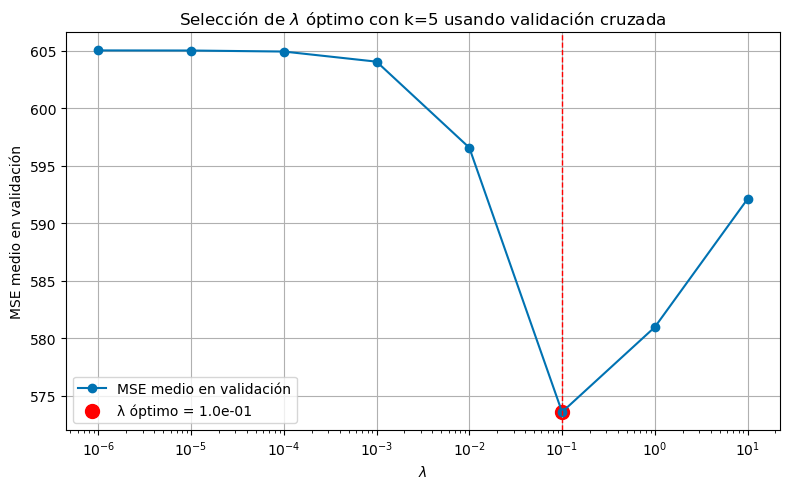

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Datos sintéticos (200 muestras, 20 características)
X, y = make_regression(n_samples=200, n_features=20, noise=25,
                       effective_rank=5, random_state=42)

# Valores candidatos de lambda (alpha)
lambdas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]

# Número de pliegues k
k = 5

# Lista para guardar el error medio de validación para cada lambda
val_errors_mean = []

# Validación cruzada
kf = KFold(n_splits=k, shuffle=True, random_state=42)

for alpha in lambdas:
    fold_errors = []
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        fold_errors.append(mean_squared_error(y_val, y_val_pred))
    
    # Guardar el error medio para este lambda
    val_errors_mean.append(np.mean(fold_errors))

# Seleccionar lambda óptimo
val_errors_mean = np.array(val_errors_mean)
best_idx = np.argmin(val_errors_mean)
best_lambda = lambdas[best_idx]

print(f"λ óptimo encontrado: {best_lambda:.1e}")

# 6Gráfica del proceso
plt.figure(figsize=(8, 5))
plt.semilogx(lambdas, val_errors_mean, marker='o', label='MSE medio en validación')
plt.scatter(best_lambda, val_errors_mean[best_idx], color='red', s=100,
            label=f"λ óptimo = {best_lambda:.1e}")
plt.axvline(best_lambda, color='red', linestyle='--', linewidth=1)
plt.xlabel("$\\lambda$")
plt.ylabel("MSE medio en validación")
plt.title(f"Selección de $\\lambda$ óptimo con k={k} usando validación cruzada")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## ¿Cómo se escoge el $\lambda$ óptimo?

En regularización, $\lambda$ controla la complejidad del modelo:  
- $\lambda$ pequeño → modelo flexible (posible sobreajuste).  
- $\lambda$ grande → modelo simple (posible subajuste).

### Procedimiento para seleccionar $\lambda^*$:

1. Se elige un conjunto de valores candidatos para $\lambda$ (en escala logarítmica).
2. Para cada valor de $\lambda$:
   - Se entrena el modelo $k$ veces (validación cruzada).
   - Se calcula el **error medio de validación**:
     $$
     \text{MSE}_\text{val}(\lambda) = \frac{1}{k} \sum_{i=1}^{k} \mathcal{L}_\text{val}^{(i)}(\lambda)
     $$
3. Se compara el error medio entre todos los valores de $\lambda$.
4. Se selecciona el valor que **minimiza el error de validación**:
   $$
   \lambda^* = \arg\min_\lambda \text{MSE}_\text{val}(\lambda)
   $$
5. Este $\lambda^*$ representa el mejor equilibrio entre **sesgo y varianza**.



λ óptimo encontrado: 1.0e-01


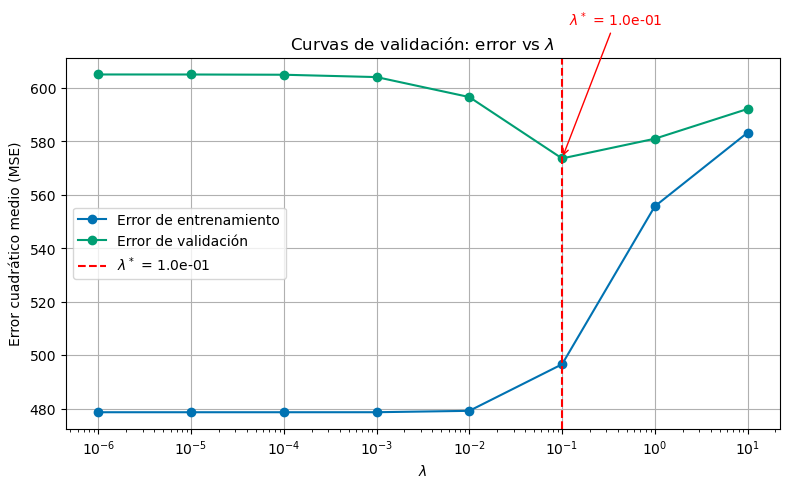

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Datos sintéticos
X, y = make_regression(n_samples=200, n_features=20, noise=25,
                       effective_rank=5, random_state=42)

# Valores candidatos de lambda (alpha)
lambdas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]

# Número de pliegues k
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Listas para guardar errores promedio
train_errors_mean = []
val_errors_mean = []

# Validación cruzada para cada lambda
for alpha in lambdas:
    fold_train_errors = []
    fold_val_errors = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        
        fold_train_errors.append(mean_squared_error(y_train, y_train_pred))
        fold_val_errors.append(mean_squared_error(y_val, y_val_pred))
    
    train_errors_mean.append(np.mean(fold_train_errors))
    val_errors_mean.append(np.mean(fold_val_errors))

# Determinar lambda óptimo
val_errors_mean = np.array(val_errors_mean)
best_idx = np.argmin(val_errors_mean)
lambda_optimo = lambdas[best_idx]
print(f"λ óptimo encontrado: {lambda_optimo:.1e}")

# Gráfica con línea vertical
plt.figure(figsize=(8, 5))
plt.semilogx(lambdas, train_errors_mean, marker='o', label='Error de entrenamiento')
plt.semilogx(lambdas, val_errors_mean, marker='o', label='Error de validación')
plt.axvline(lambda_optimo, color='red', linestyle='--', linewidth=1.5, label=f"$\\lambda^*$ = {lambda_optimo:.1e}")
plt.annotate(f"$\\lambda^*$ = {lambda_optimo:.1e}",
             xy=(lambda_optimo, val_errors_mean[best_idx]),
             xytext=(lambda_optimo*1.2, val_errors_mean[best_idx] + 50),
             arrowprops=dict(arrowstyle="->", color="red"),
             fontsize=10, color="red")

plt.xlabel("$\\lambda$")
plt.ylabel("Error cuadrático medio (MSE)")
plt.title("Curvas de validación: error vs $\\lambda$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Búsqueda Exhaustiva (Grid Search) 

En este ejemplo, se busca el valor óptimo de $\lambda$ para la regularización de un modelo Ridge mediante **búsqueda exhaustiva (grid search)**.  
Se definen varios valores de $\lambda$ y se evalúa el modelo para cada uno usando validación cruzada.

Al generar datos sintéticos con muchas características y alto nivel de ruido:
- Para $\lambda$ muy pequeño, el modelo se sobreajusta (overfitting) y el error en validación aumenta.
- Para $\lambda$ muy grande, el modelo se subajusta (underfitting) y el error también aumenta.
- En un valor intermedio de $\lambda$, se obtiene el error más bajo.

> La instrucción: lambdas = np.logspace(-2, 2, 30)
> genera un arreglo de 30 números distribuidos logarítmicamente entre: [$10^{-2} = 0.01$ y $10^{5} = 100$]


Lambda óptimo encontrado: 5.736152510448681


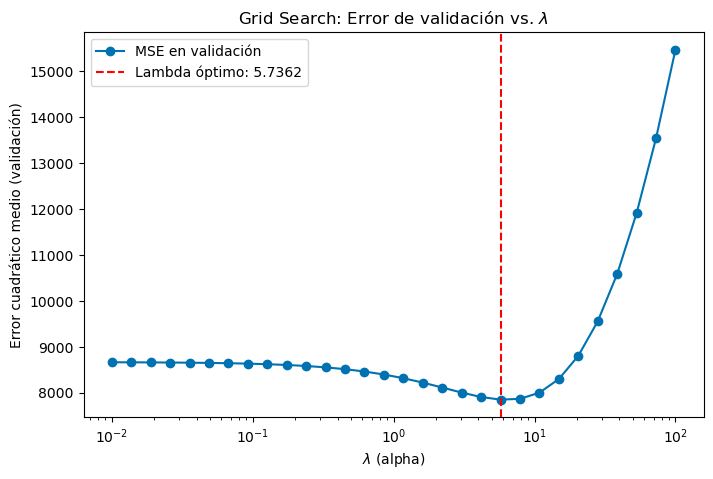

In [67]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Generar datos sintéticos complejos para forzar sobreajuste y subajuste
# Más muestras y más características + ruido alto
X, y = make_regression(n_samples=200, n_features=100, noise=50, random_state=42)

# Definir conjunto discreto de posibles valores de lambda (alpha en scikit-learn)
lambdas = np.logspace(-2, 2, 30)

# Configurar modelo y búsqueda exhaustiva
ridge = Ridge()
param_grid = {'alpha': lambdas}
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')

# Ejecutar búsqueda
grid_search.fit(X, y)

# Extraer resultados
mean_errors = -grid_search.cv_results_['mean_test_score']
best_lambda = grid_search.best_params_['alpha']

# Mostrar resultados
print(f"Lambda óptimo encontrado: {best_lambda}")

# Graficar error vs lambda
plt.figure(figsize=(8, 5))
plt.semilogx(lambdas, mean_errors, marker='o', label='MSE en validación')
plt.axvline(best_lambda, color='r', linestyle='--', label=f'Lambda óptimo: {best_lambda:.4f}')
plt.xlabel('$\\lambda$ (alpha)')
plt.ylabel('Error cuadrático medio (validación)')
plt.title('Grid Search: Error de validación vs. $\\lambda$')
plt.legend()
plt.show()


# Hiperparámetro número de épocas

Al entrenar redes neuronales, el número de épocas ($\text{epochs}$) es un hiperparámetro clave:

- **Pocas épocas → subajuste (underfitting):**  
  El modelo no logra capturar los patrones relevantes y el error de validación es alto.
- **Muchas épocas → sobreajuste (overfitting):**  
  El modelo aprende demasiado bien los datos de entrenamiento, perdiendo capacidad de generalización y aumentando el error de validación.
- **Número intermedio → óptimo:**  
  Se logra el menor error en validación, equilibrando la complejidad y la capacidad de generalización.

En el ejemplo:
- Se evalúa el error de validación con **validación cruzada (cross-validation)** para distintos valores de épocas.
- Se observa una **curva cuadrática (en forma de U):** el error es alto con pocas o muchas épocas y bajo en un punto intermedio.
- Se selecciona como óptimo el número de épocas que minimiza el error promedio de validación.

$$
\min_{\text{epochs}} \text{Error de validación}
$$

Esta técnica permite ajustar de forma objetiva el número de épocas y evitar tanto el underfitting como el overfitting.

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier

# Generar datos sintéticos con más ruido para forzar overfitting
X, y = make_classification(n_samples=500, n_features=20, n_informative=10,
                           n_redundant=5, flip_y=0.15, class_sep=0.8, random_state=42)

# Definir rango de épocas más amplio para que se vea mejor el efecto
epochs = [1, 5, 10, 20, 50, 100, 200, 300, 400, 500]

val_errors = []

# Validación cruzada para cada número de épocas
for ep in epochs:
    clf = MLPClassifier(hidden_layer_sizes=(50,), max_iter=ep, random_state=42)
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    val_error = 1 - np.mean(scores)
    val_errors.append(val_error)

# Encontrar el número óptimo de épocas (mínimo error)
val_errors = np.array(val_errors)
best_idx = np.argmin(val_errors)
best_epoch = epochs[best_idx]
best_error = val_errors[best_idx]

C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users

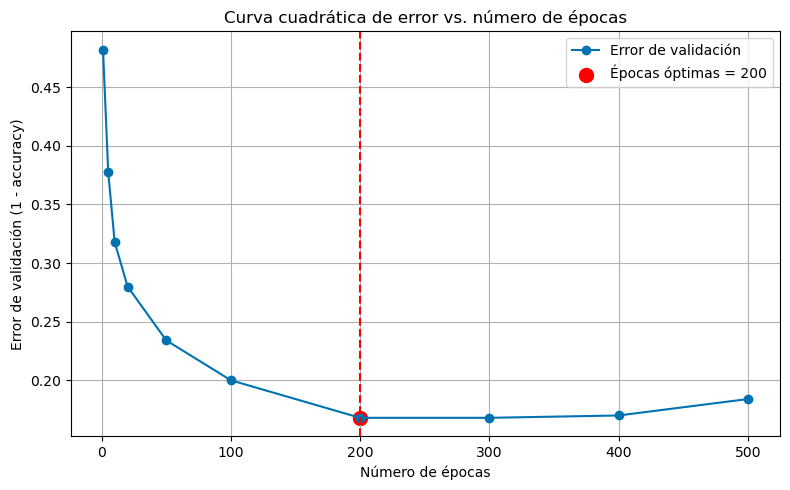

Número óptimo de épocas: 200 con error de validación 0.1680


In [78]:
# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(epochs, val_errors, marker='o', label='Error de validación')
plt.scatter(best_epoch, best_error, color='red', s=100, label=f'Épocas óptimas = {best_epoch}')
plt.axvline(best_epoch, color='red', linestyle='--')
plt.xlabel('Número de épocas')
plt.ylabel('Error de validación (1 - accuracy)')
plt.title('Curva cuadrática de error vs. número de épocas')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Número óptimo de épocas: {best_epoch} con error de validación {best_error:.4f}')

## Early stopping (ejemplo práctico)
**¿Qué hace este ejemplo?**

- Usa el argumento `early_stopping=True` del `MLPClassifier` de scikit-learn para activar la detención temprana.
- Supervisa el error de validación en un conjunto de validación interno definido con `validation_fraction=0.2`.
- Se detiene automáticamente si el error de validación no mejora durante `n_iter_no_change=10` épocas consecutivas (patience).
- Al finalizar, muestra:
  - El número real de épocas entrenadas hasta que se activó el early stopping.
  - La curva de pérdida en el conjunto de entrenamiento.
  - Una línea vertical que indica la época donde se detuvo el entrenamiento.

 Esta técnica ayuda a evitar el sobreajuste (overfitting) y a reducir el tiempo de entrenamiento, asegurando que el modelo mantenga una buena capacidad de generalización.


Número de épocas entrenadas hasta early stopping: 55
Error de validación final: 0.1100


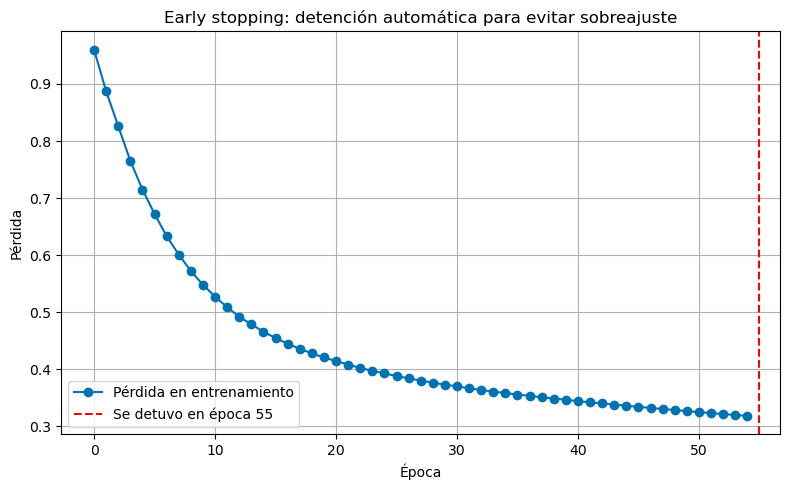

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Generar datos sintéticos con ruido para forzar overfitting
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, 
                           n_redundant=5, flip_y=0.1, random_state=42)

# Dividir en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Configurar modelo con early stopping
clf = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500,
                    early_stopping=True, validation_fraction=0.2,
                    n_iter_no_change=10, random_state=42)

# Entrenar modelo
clf.fit(X_train, y_train)

# Número real de épocas entrenadas
n_epochs_trained = clf.n_iter_

# Calcular accuracy final en validación
y_pred = clf.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred)
val_error = 1 - val_accuracy

print(f"Número de épocas entrenadas hasta early stopping: {n_epochs_trained}")
print(f"Error de validación final: {val_error:.4f}")

# Mostrar curva de pérdida durante el entrenamiento
plt.figure(figsize=(8, 5))
plt.plot(clf.loss_curve_, marker='o', label='Pérdida en entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Early stopping: detención automática para evitar sobreajuste')
plt.axvline(n_epochs_trained, color='red', linestyle='--', label=f'Se detuvo en época {n_epochs_trained}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
